In [670]:
import pandas as pd
import plotly.express as px
import re
from difflib import SequenceMatcher
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np
import seaborn as sns
from itertools import combinations
from collections import Counter
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet
import itertools
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import warnings

warnings.filterwarnings('ignore')

## 4.1 Data Description and Preparation

In [671]:
fabrics = pd.read_csv("продажі 21-25 тканини.csv", sep=";")
buttons = pd.read_csv("продажі гудзики 2021-2025.csv", sep=";")

In [672]:
def preprocess(df):
    """
    fix types
    add columns from date
    fix column names
    """
    df = df.copy()

    df["Дата"] = pd.to_datetime(
        df["Дата"].str.replace(" г.", "", regex=False),
        dayfirst=True
    )

    numeric_cols = ["Кількість", "Ціна продажу", "Вар-сть продажу"]
    for col in numeric_cols:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", ".", regex=False)
            .astype(float)
        )
    df['year']=df['Дата'].dt.year
    df['month']=df['Дата'].dt.month
    df['day']=df['Дата'].dt.day
    df.drop(columns=["В т.ч. ПДВ продажу",'В т.ч. вар-сть ПДВ продажу'], axis=1, inplace=True)
    df.rename(columns={'Кількість': 'quantity', 'Ціна продажу': 'price','Вар-сть продажу':'revenue','Дата':'date','Документ №':'document number','Товар':'item','Од. вим.':'measure','Магазин':'store'}, inplace=True)

    return df

In [673]:
buttons = preprocess(buttons)
fabrics = preprocess(fabrics)

In [674]:
sales = pd.concat([buttons, fabrics])
sales

,document number,date,item,quantity,measure,price,revenue,store,year,month,day
0,1,2021-01-21,Мікс №40 Полі/естр,1.0,шт.,12.0,12.0,Гудзики,2021,1,21
1,2,2021-01-22,Бісер Чехія,10.0,уп,10.0,100.0,Гудзики,2021,1,22
2,3,2021-01-22,Стр Атл 2.5см(8366) Корал,5.0,м,4.0,20.0,Гудзики,2021,1,22
3,4,2021-01-22,3047 Нитки ДМС,3.0,шт.,18.0,54.0,Гудзики,2021,1,22
4,4,2021-01-22,3045 Нитки ДМС,3.0,шт.,18.0,54.0,Гудзики,2021,1,22
...,...,...,...,...,...,...,...,...,...,...,...
13035,121751,2025-12-30,т011 Костюмна,2.8,м,700.0,1960.0,Тканини,2025,12,30
13036,121774,2025-12-30,т038 Фліс,2.0,м,300.0,600.0,Тканини,2025,12,30
13037,121801,2025-12-30,т005 Фатін,2.0,м,120.0,240.0,Тканини,2025,12,30
13038,121817,2025-12-31,т011 Костюмна,2.3,м,700.0,1610.0,Тканини,2025,12,31


Standardize item names

In [675]:
def normalize_product_name(name):
    """
    normalize the product name
    """
    if not isinstance(name, str):
        return ""

    name = name.lower().strip()
    
    name = re.sub(r'\s+', ' ', name)
    
    name = re.sub(r'[^\w\s]', ' ', name)
    
    name = ' '.join(name.split())
    
    return name

def normalize_all_product_names(df):
    """
    changing all the item names
    """
    
    df['item_original'] = df['item']
    
    df['item'] = df['item'].apply(normalize_product_name)
    
    original_count = df['item_original'].nunique()
    normalized_count = df['item'].nunique()
    
    print(f"Unique names: {original_count:,}")
    print(f"Unique normilized names: {normalized_count:,}")
    print(f"Difference: {original_count- normalized_count:,}")
    
    return df

sales = normalize_all_product_names(sales)


Unique names: 11,179
Unique normilized names: 11,161
Difference: 18


In [676]:
# examples of names that were merged
collapsed = (
    sales
    .groupby('item')['item_original']
    .nunique()
    .reset_index()
)
problem_items = collapsed[collapsed['item_original'] > 1]
for item in problem_items['item'].head(10):
    print(f"\nNORMALIZED: {item}")
    print(sales[sales['item'] == item]['item_original'].unique())


NORMALIZED: гачок білиз с о
['Гачок Білиз  (С.О)' 'Гачок Білиз (С.О)']

NORMALIZED: гудзики
['гудзики' 'Гудзики']

NORMALIZED: гудзики со
['Гудзики СО' 'Гудзики  СО']

NORMALIZED: мер х б 1495 18к біле
['Мер Х\\б 1495\\18К Біле' 'Мер Х/б 1495\\18К Біле']

NORMALIZED: мер х б 2151 9kg13
['Мер х\\б 2151/9kg13' 'Мер х/б 2151/9kg13']

NORMALIZED: мер х б 7156 80w02
['Мер х\\б 7156/80w02' 'Мер х/б 7156\\80w02']

NORMALIZED: мережгіпюр 3 5см біл с к
['МережГіпюр 3,5см Біл (С.К)' 'МережГіпюр 3,5см Біл(С.К)']

NORMALIZED: мережгіпюр 4 5см с к 13м
['МережГіпюр 4,5см (С.К) 13м' 'МережГіпюр 4,5см (С.К)13м']

NORMALIZED: нашивки шкіряні с о
['Нашивки Шкіряні (С.О)' 'Нашивки Шкіряні С.О']

NORMALIZED: пряжка 709 3 5см с к
['Пряжка №709 (3,5см) С.К' 'Пряжка 709\\3,5см (С.К)']


In [677]:
# get rid ot unknown item
# can not analize it since the price is not correct
sales = sales.loc[sales['item']!='невизначений товар']

## 4.2 Exploratory Data Analysis

#### 4.2.1 Dataset Overview

In [678]:
sales.shape
sales.info()
sales.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 258645 entries, 0 to 13039
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   document number  258645 non-null  int64         
 1   date             258645 non-null  datetime64[ns]
 2   item             258645 non-null  object        
 3   quantity         258645 non-null  float64       
 4   measure          258644 non-null  object        
 5   price            258645 non-null  float64       
 6   revenue          258645 non-null  float64       
 7   store            258645 non-null  object        
 8   year             258645 non-null  int32         
 9   month            258645 non-null  int32         
 10  day              258645 non-null  int32         
 11  item_original    258644 non-null  object        
dtypes: datetime64[ns](1), float64(3), int32(3), int64(1), object(4)
memory usage: 22.7+ MB


,document number,date,quantity,price,revenue,year,month,day
count,258645.000000,258645,258645.000000,258645.000000,258645.000000,258645.000000,258645.000000,258645.000000
mean,51836.021299,2023-06-10 19:27:44.689438976,2.949377,46.581770,81.067260,2022.931547,6.634948,15.886752
min,1.000000,2021-01-21 00:00:00,0.050000,0.010000,0.010000,2021.000000,1.000000,1.000000
25%,25563.000000,2022-04-12 00:00:00,1.000000,10.000000,18.000000,2022.000000,4.000000,8.000000
50%,42179.000000,2023-05-04 00:00:00,1.000000,20.000000,30.000000,2023.000000,7.000000,16.000000
75%,79396.000000,2024-08-20 00:00:00,2.000000,45.000000,72.000000,2024.000000,10.000000,23.000000
max,121864.000000,2025-12-31 00:00:00,1740.000000,1950.000000,31050.000000,2025.000000,12.000000,31.000000
std,33812.292310,NaN,10.147013,86.909672,245.598676,1.374905,3.432903,8.718092


In [679]:
sales['date'].min(), sales['date'].max()

(Timestamp('2021-01-21 00:00:00'), Timestamp('2025-12-31 00:00:00'))

In [680]:
sales.index.nunique()

246535

##### Store-Level Comparison 

In [681]:
def descriptive_stats(df, store_name):
    subset = df[df['store'] == store_name]
    print(f"\n {store_name}:")
    print(f"   • Records: {len(subset):,}")
    print(f"   • Unique products: {subset['item'].nunique():,}")
    print(f"   • Unique receipts: {subset.index.nunique():,}")
    print(f"   • Date range: {subset['date'].min()} — {subset['date'].max()}")
    print(f"   • Total revenue: {subset['revenue'].sum():,.2f}")
    print(f"   • Avg receipt value: {subset.groupby(subset.index)['revenue'].sum().mean():.2f}")
    print(f"   • Avg items per receipt: {subset.groupby(subset.index).size().mean():.2f}")

descriptive_stats(sales, "Тканини")
descriptive_stats(sales, "Гудзики")

# Overall summary
print("\n TOTAL (Both stores):")
print(f"   • Total records: {len(sales):,}")
print(f"   • Total unique products: {sales['item'].nunique():,}")
print(f"   • Total revenue: {sales['revenue'].sum():,.2f}")


 Тканини:
   • Records: 12,188
   • Unique products: 141
   • Unique receipts: 12,188
   • Date range: 2021-02-25 00:00:00 — 2025-12-31 00:00:00
   • Total revenue: 5,440,234.44
   • Avg receipt value: 446.36
   • Avg items per receipt: 1.00

 Гудзики:
   • Records: 246,457
   • Unique products: 11,073
   • Unique receipts: 246,457
   • Date range: 2021-01-21 00:00:00 — 2025-12-31 00:00:00
   • Total revenue: 15,527,406.94
   • Avg receipt value: 63.00
   • Avg items per receipt: 1.00

 TOTAL (Both stores):
   • Total records: 258,645
   • Total unique products: 11,160
   • Total revenue: 20,967,641.38


### 4.2.2 Product-Level Analysis 

#### Price Distribution


Гудзики price percentiles:
   10th: 5.33
   25th: 11.15
   50th (median): 22.34
   75th: 65.00
   90th: 120.00
   99th: 480.00

Тканини price percentiles:
   10th: 65.07
   25th: 160.11
   50th (median): 294.07
   75th: 455.71
   90th: 670.00
   99th: 1020.00


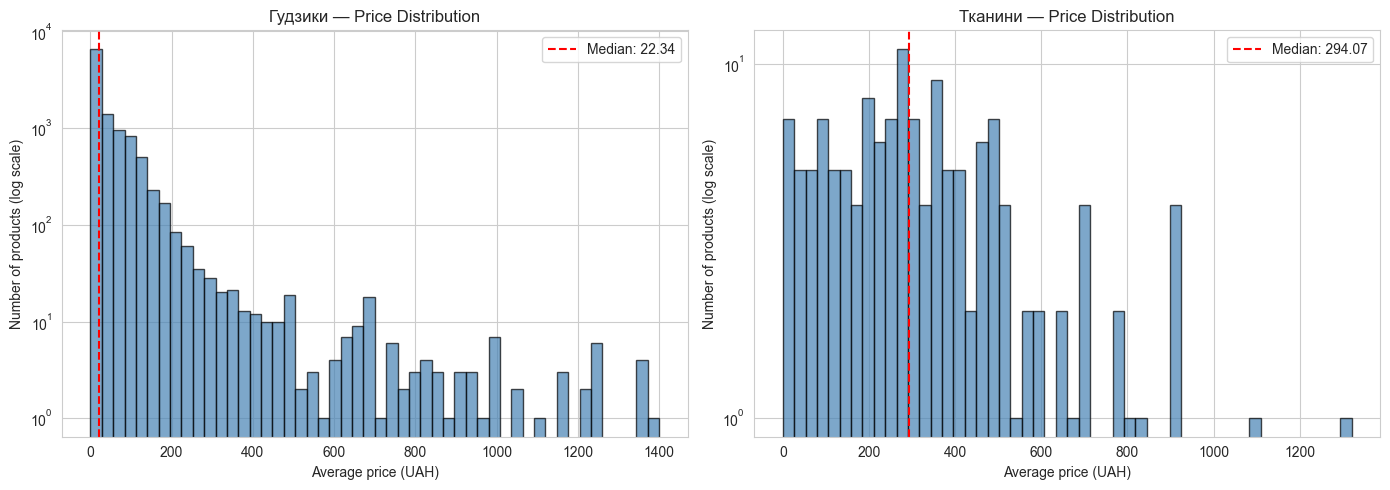

In [682]:
product_price = sales.groupby(['store', 'item'])['price'].mean().reset_index()


for store in ['Гудзики', 'Тканини']:
    prices = product_price[product_price['store'] == store]['price']
    print(f"\n{store} price percentiles:")
    print(f"   10th: {prices.quantile(0.1):.2f}")
    print(f"   25th: {prices.quantile(0.25):.2f}")
    print(f"   50th (median): {prices.median():.2f}")
    print(f"   75th: {prices.quantile(0.75):.2f}")
    print(f"   90th: {prices.quantile(0.9):.2f}")
    print(f"   99th: {prices.quantile(0.99):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, store in zip(axes, ['Гудзики', 'Тканини']):
    prices = product_price[product_price['store'] == store]['price']
    ax.hist(prices, bins=50, alpha=0.7, edgecolor='black', color='steelblue')
    ax.set_yscale('log')
    ax.set_title(f'{store} — Price Distribution', fontsize=12)
    ax.set_xlabel('Average price (UAH)')
    ax.set_ylabel('Number of products (log scale)')
    ax.axvline(prices.median(), color='red', linestyle='--', label=f'Median: {prices.median():.2f}')
    ax.legend()

plt.tight_layout()
plt.show()

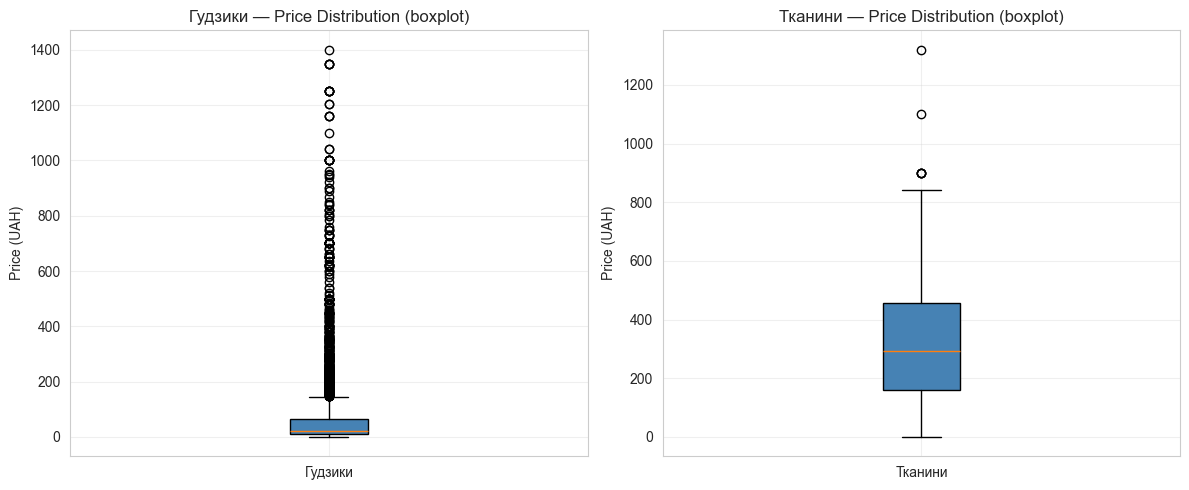

In [683]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, store in zip(axes, ['Гудзики', 'Тканини']):
    prices = product_price[product_price['store'] == store]['price']
    bp = ax.boxplot(prices, vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    ax.set_title(f'{store} — Price Distribution (boxplot)', fontsize=12)
    ax.set_ylabel('Price (UAH)')
    ax.set_xticklabels([store])
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Frequency Analysis 

In [684]:
product_freq = sales.groupby(['store', 'item'])['revenue'].count().reset_index()
product_freq.rename(columns={'revenue': 'checks'}, inplace=True)

print("\n Frequency percentiles:")
for store in ['Гудзики', 'Тканини']:
    freqs = product_freq[product_freq['store'] == store]['checks']
    print(f"\n{store}:")
    print(f"   10th: {freqs.quantile(0.1):.0f}")
    print(f"   25th: {freqs.quantile(0.25):.0f}")
    print(f"   50th (median): {freqs.median():.0f}")
    print(f"   75th: {freqs.quantile(0.75):.0f}")
    print(f"   90th: {freqs.quantile(0.9):.0f}")
    print(f"   99th: {freqs.quantile(0.99):.0f}")

n_fabrics = len(product_freq[product_freq['store'] == 'Тканини'])
bins_fabrics = max(10, int(np.log2(n_fabrics) + 1))
print(f"\n Fabrics: {n_fabrics} products → using {bins_fabrics} bins for histogram")




 Frequency percentiles:

Гудзики:
   10th: 1
   25th: 2
   50th (median): 5
   75th: 15
   90th: 42
   99th: 291

Тканини:
   10th: 1
   25th: 3
   50th (median): 21
   75th: 89
   90th: 257
   99th: 659

 Fabrics: 141 products → using 10 bins for histogram


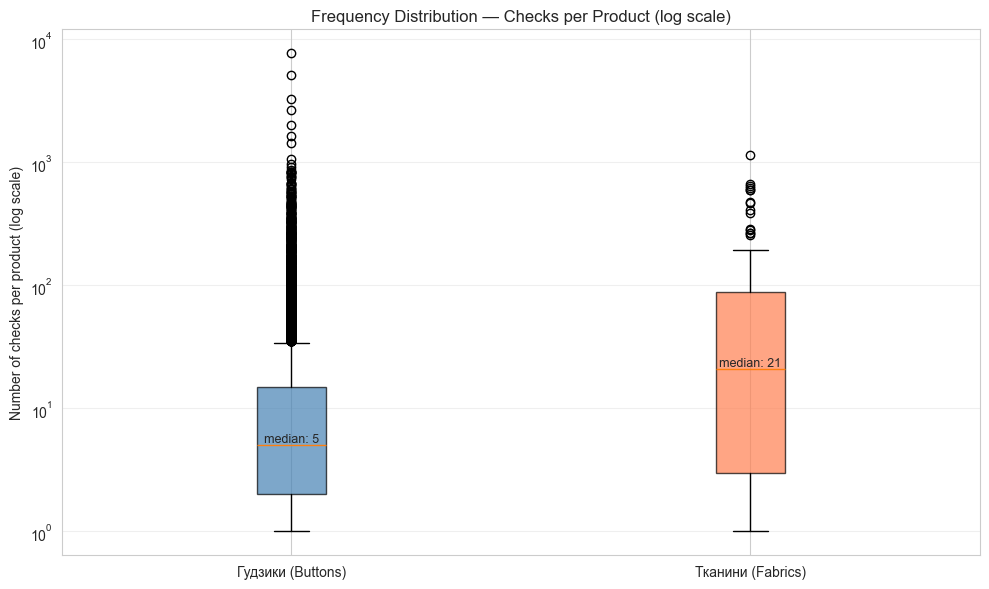

In [685]:
fig, ax = plt.subplots(figsize=(10, 6))

data_to_plot = [
    product_freq[product_freq['store'] == 'Гудзики']['checks'],
    product_freq[product_freq['store'] == 'Тканини']['checks']
]

bp = ax.boxplot(data_to_plot, labels=['Гудзики (Buttons)', 'Тканини (Fabrics)'], 
                patch_artist=True, showmeans=False, whis=1.5)

bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('coral')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_alpha(0.7)

ax.set_yscale('log')
ax.set_title('Frequency Distribution — Checks per Product (log scale)', fontsize=12)
ax.set_ylabel('Number of checks per product (log scale)')
ax.grid(True, alpha=0.3, axis='y')

ax.text(1, 5, f'median: 5', ha='center', va='bottom', fontsize=9)
ax.text(2, 21, f'median: 21', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### 4.2.3 Yearly Analysis

#### Metrics by Year


Yearly statistics (Nominal vs Real):
  store  year  revenue_m  real_revenue_m  unique_products  median_price
Гудзики  2021       1.85            1.85             6544          15.0
Гудзики  2022       3.34            2.64             6761          20.0
Гудзики  2023       3.37            2.53             5805          22.0
Гудзики  2024       3.36            2.25             5073          22.0
Гудзики  2025       3.62            2.25             4238          25.0
Тканини  2021       0.50            0.50               77         160.0
Тканини  2022       1.01            0.79               96         180.0
Тканини  2023       1.20            0.90               94         200.0
Тканини  2024       1.30            0.87               99         210.0
Тканини  2025       1.43            0.89              103         250.0


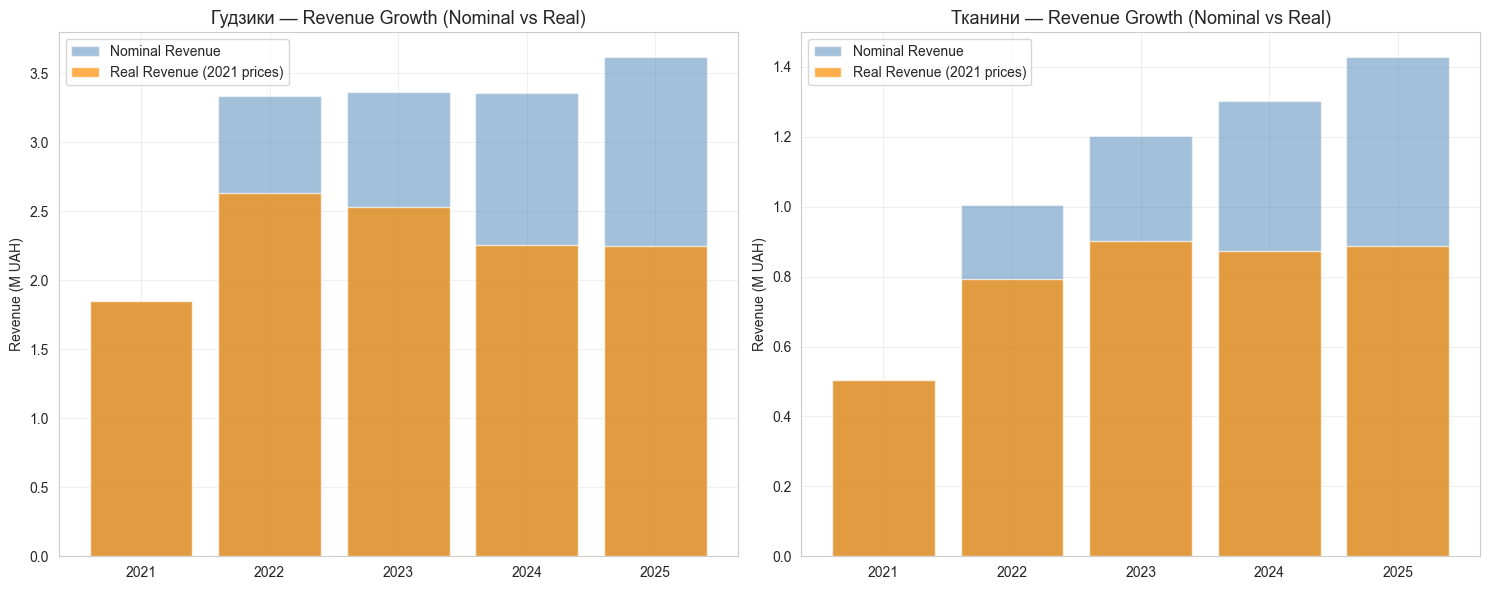

In [686]:
cpi_map = {2021: 1.00, 2022: 1.266, 2023: 1.3305, 2024: 1.4902, 2025: 1.6094}

yearly_stats = sales.groupby(['store', 'year']).agg(
    revenue=('revenue', 'sum'),
    unique_products=('item', 'nunique'),
    median_price=('price', 'median')
).reset_index()

yearly_stats['cpi_cum'] = yearly_stats['year'].map(cpi_map)
yearly_stats['real_revenue'] = yearly_stats['revenue'] / yearly_stats['cpi_cum']

yearly_stats['revenue_m'] = yearly_stats['revenue'] / 1_000_000
yearly_stats['real_revenue_m'] = yearly_stats['real_revenue'] / 1_000_000

print("\nYearly statistics (Nominal vs Real):")
print(yearly_stats[['store', 'year', 'revenue_m', 'real_revenue_m', 'unique_products', 'median_price']].round(2).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, store in zip(axes, ['Гудзики', 'Тканини']):
    store_data = yearly_stats[yearly_stats['store'] == store]
    ax.bar(store_data['year'].astype(str), store_data['revenue_m'], label='Nominal Revenue', alpha=0.5, color='steelblue')
    ax.bar(store_data['year'].astype(str), store_data['real_revenue_m'], label='Real Revenue (2021 prices)', alpha=0.7, color='darkorange')
    ax.set_title(f'{store} — Revenue Growth (Nominal vs Real)', fontsize=13)
    ax.set_ylabel('Revenue (M UAH)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

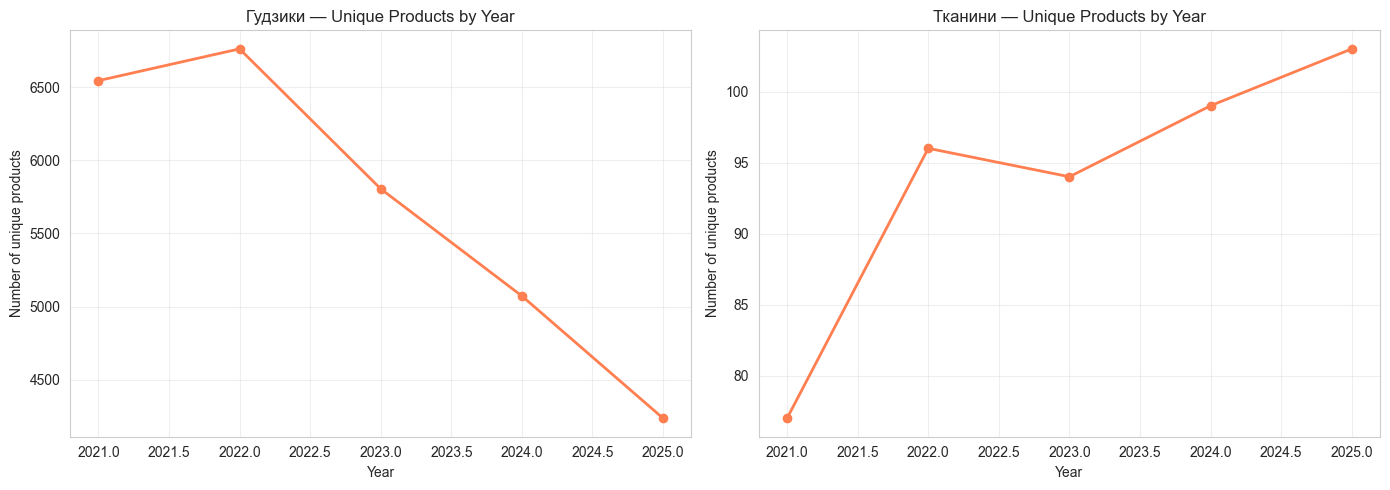

In [687]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, store in zip(axes, ['Гудзики', 'Тканини']):
    store_data = yearly_stats[yearly_stats['store'] == store]
    ax.plot(store_data['year'], store_data['unique_products'], marker='o', linewidth=2, color='coral')
    ax.set_title(f'{store} — Unique Products by Year', fontsize=12)
    ax.set_xlabel('Year')
    ax.set_ylabel('Number of unique products')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### New Products


 New products by year:
  store  first_year  new_products
Гудзики        2021          6544
Гудзики        2022          2156
Гудзики        2023          1206
Гудзики        2024           666
Гудзики        2025           501
Тканини        2021            77
Тканини        2022            26
Тканини        2023             9
Тканини        2024            11
Тканини        2025            18


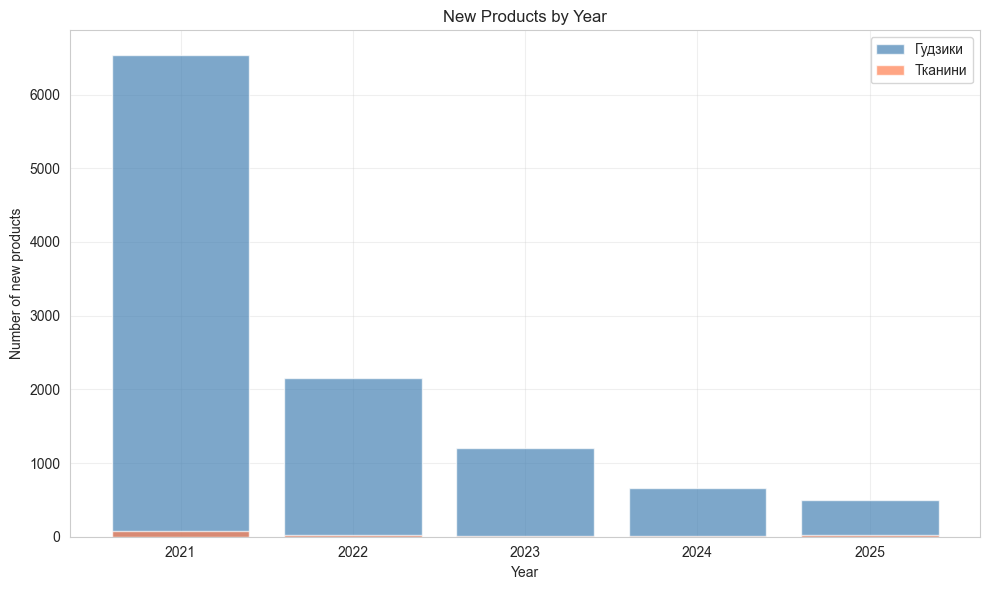

In [523]:
first_seen = sales.groupby(['store', 'item'])['year'].min().reset_index()
first_seen.columns = ['store', 'item', 'first_year']

new_products = first_seen.groupby(['store', 'first_year']).size().reset_index(name='new_products')

print("\n New products by year:")
print(new_products.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))

for store in ['Гудзики', 'Тканини']:
    data = new_products[new_products['store'] == store]
    ax.bar(data['first_year'].astype(str), data['new_products'], alpha=0.7, 
           label=store, color='steelblue' if store == 'Гудзики' else 'coral')

ax.set_title('New Products by Year', fontsize=12)
ax.set_xlabel('Year')
ax.set_ylabel('Number of new products')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.2.4 Time-Based Analysis

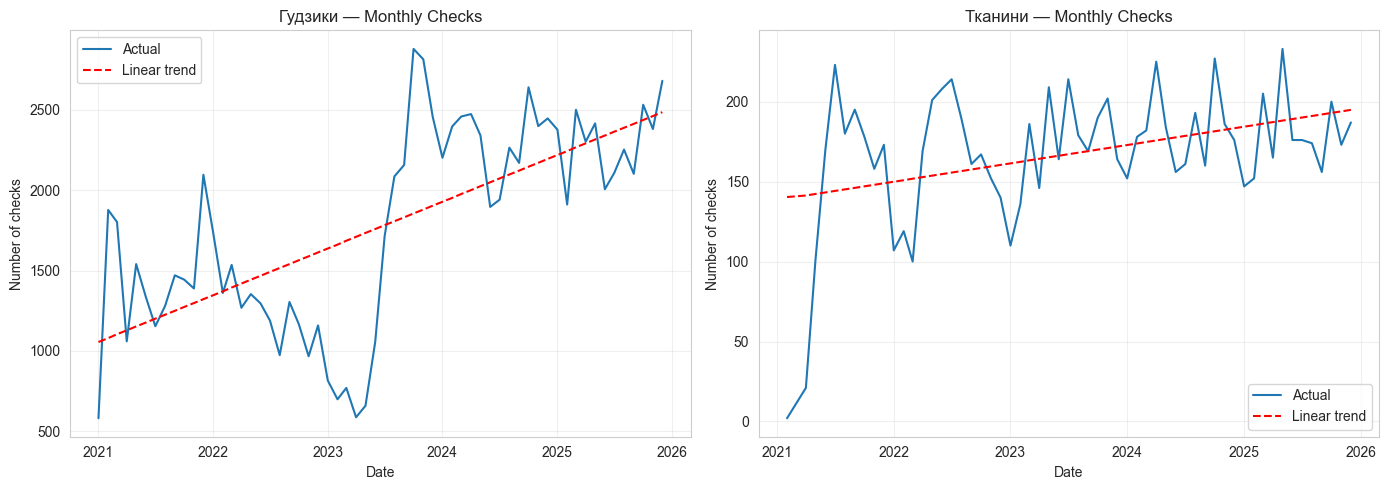

In [689]:
monthly = sales.groupby(['store', 'year', 'month'])['document number'].nunique().reset_index()
monthly.columns = ['store', 'year', 'month', 'checks']
monthly['date'] = pd.to_datetime(monthly['year'].astype(str) + '-' + monthly['month'].astype(str) + '-01')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, store in zip(axes, ['Гудзики', 'Тканини']):
    data = monthly[monthly['store'] == store].copy()
    ax.plot(data['date'], data['checks'], linewidth=1.5, label='Actual')

    x = np.arange(len(data))
    z = np.polyfit(x, data['checks'], 1)
    p = np.poly1d(z)
    ax.plot(data['date'], p(x), 'r--', linewidth=1.5, label='Linear trend')
    
    ax.set_title(f'{store} — Monthly Checks', fontsize=12)
    ax.set_xlabel('Date')
    ax.set_ylabel('Number of checks')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [690]:
seasonal_by_year = []

for store in ['Гудзики', 'Тканини']:
    for year in sales['year'].unique():
        year_data = sales[(sales['store'] == store) & (sales['year'] == year)]
        monthly_counts = year_data.groupby('month')['document number'].nunique()
        if len(monthly_counts) == 12:
            seasonal_idx = monthly_counts / monthly_counts.mean() * 100
            seasonal_by_year.append(pd.DataFrame({
                'store': store,
                'month': monthly_counts.index,
                'seasonal_index': seasonal_idx.values
            }))

seasonal_df = pd.concat(seasonal_by_year)
seasonal_avg = seasonal_df.groupby(['store', 'month'])['seasonal_index'].mean().reset_index()

print("\n📊 Seasonal Index (detrended, >110 = peak, <90 = low):")
for store in ['Гудзики', 'Тканини']:
    print(f"\n{store}:")
    data = seasonal_avg[seasonal_avg['store'] == store]
    for _, row in data.iterrows():
        indicator = "PEAK" if row['seasonal_index'] > 110 else "LOW" if row['seasonal_index'] < 90 else "•"
        print(f"   Month {int(row['month'])}: {row['seasonal_index']:.1f}% {indicator}")


📊 Seasonal Index (detrended, >110 = peak, <90 = low):

Гудзики:
   Month 1: 85.7% LOW
   Month 2: 94.2% •
   Month 3: 102.5% •
   Month 4: 83.9% LOW
   Month 5: 92.7% •
   Month 6: 86.6% LOW
   Month 7: 92.1% •
   Month 8: 99.4% •
   Month 9: 106.0% •
   Month 10: 120.6% PEAK
   Month 11: 112.4% PEAK
   Month 12: 123.9% PEAK

Тканини:
   Month 1: 74.1% LOW
   Month 2: 84.0% LOW
   Month 3: 96.3% •
   Month 4: 101.5% •
   Month 5: 119.5% PEAK
   Month 6: 102.3% •
   Month 7: 111.1% PEAK
   Month 8: 106.3% •
   Month 9: 93.4% •
   Month 10: 112.8% PEAK
   Month 11: 102.8% •
   Month 12: 96.0% •


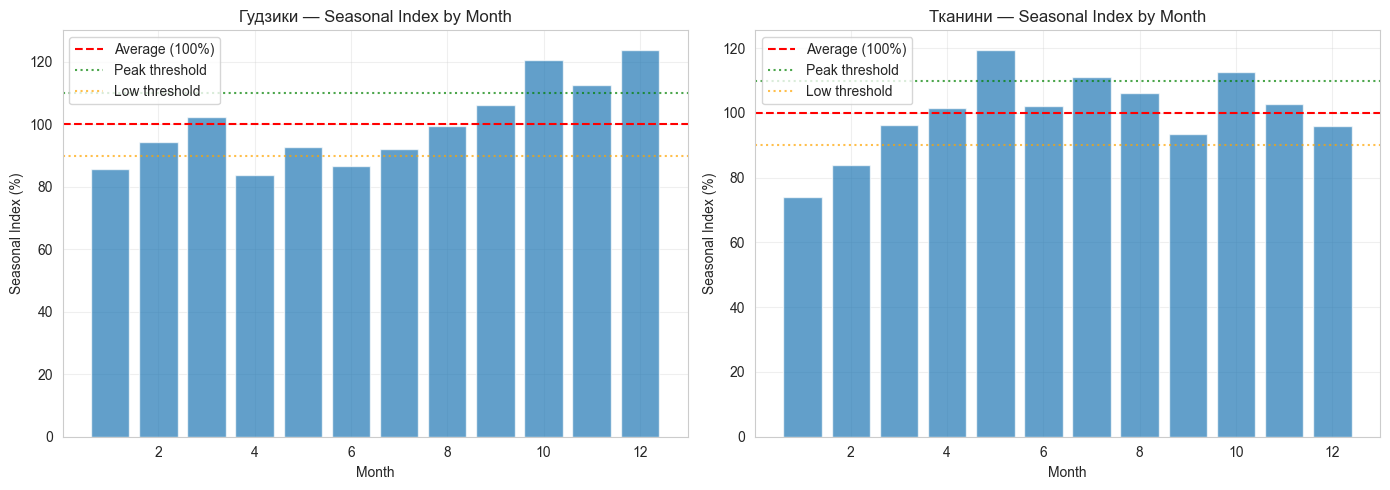

In [691]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, store in zip(axes, ['Гудзики', 'Тканини']):
    data = seasonal_avg[seasonal_avg['store'] == store]
    ax.bar(data['month'], data['seasonal_index'], alpha=0.7)
    ax.axhline(100, color='red', linestyle='--', label='Average (100%)')
    ax.axhline(110, color='green', linestyle=':', alpha=0.7, label='Peak threshold')
    ax.axhline(90, color='orange', linestyle=':', alpha=0.7, label='Low threshold')
    ax.set_title(f'{store} — Seasonal Index by Month', fontsize=12)
    ax.set_xlabel('Month')
    ax.set_ylabel('Seasonal Index (%)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [692]:
print("\nCoefficient of Variation (by month, detrended):")
for store in ['Гудзики', 'Тканини']:
    data = seasonal_avg[seasonal_avg['store'] == store]
    cv = data['seasonal_index'].std() / data['seasonal_index'].mean()
    print(f"   {store}: CV = {cv:.3f}")
    if cv < 0.3:
        print(f"      Low variation, no strong seasonality")
    else:
        print(f"      Moderate variation, possible seasonality")



Coefficient of Variation (by month, detrended):
   Гудзики: CV = 0.134
      Low variation, no strong seasonality
   Тканини: CV = 0.125
      Low variation, no strong seasonality


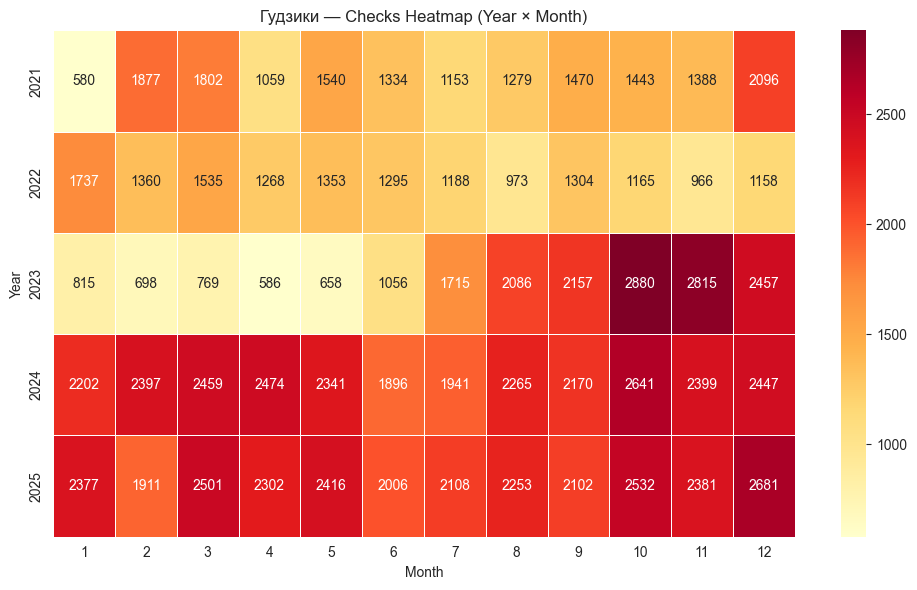

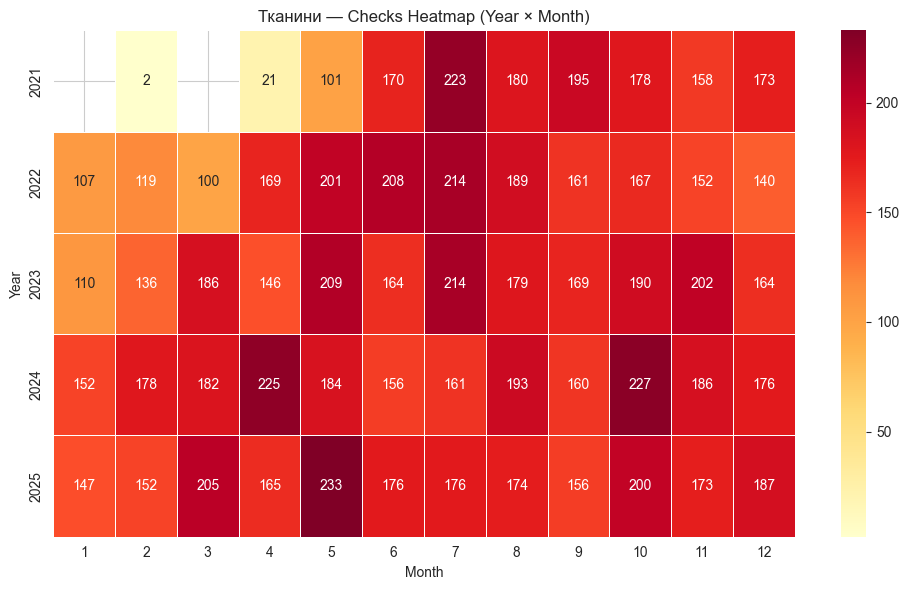

In [693]:
for store in ['Гудзики', 'Тканини']:
    data = monthly[monthly['store'] == store].pivot(index='year', columns='month', values='checks')
    # print(data)
    plt.figure(figsize=(10, 6))
    sns.heatmap(data, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
    plt.title(f'{store} — Checks Heatmap (Year × Month)', fontsize=12)
    plt.xlabel('Month')
    plt.ylabel('Year')
    plt.tight_layout()
    plt.show()

<Figure size 1200x400 with 0 Axes>

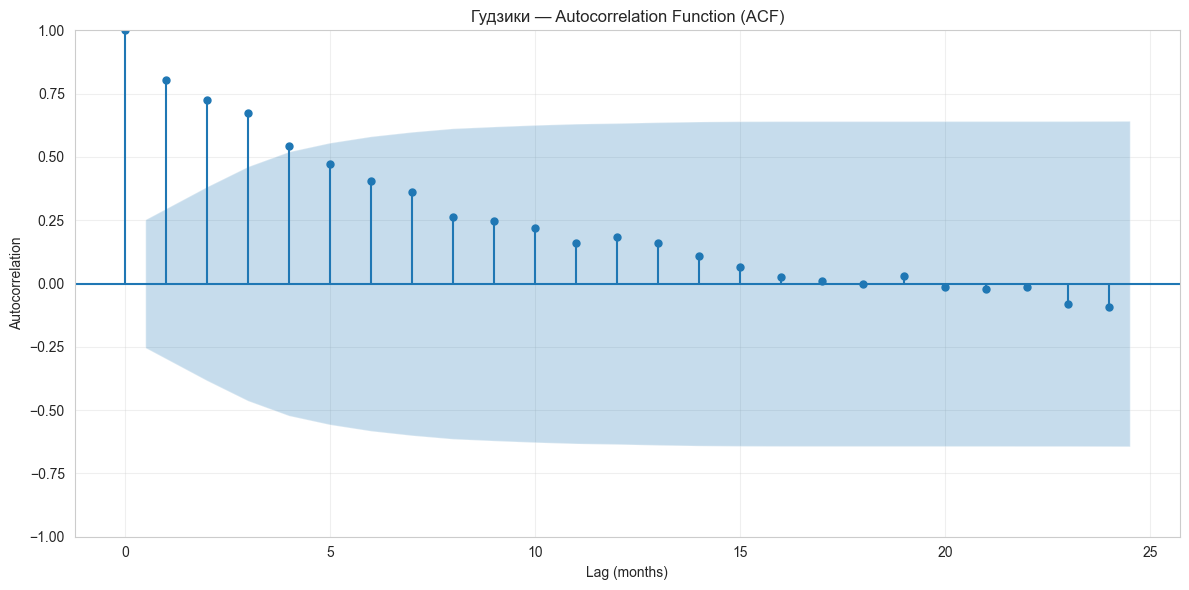


Гудзики: Significant lags at: [1, 2, 3, 4, 5]...
   → Lag 12 is NOT significant — no strong seasonality


<Figure size 1200x400 with 0 Axes>

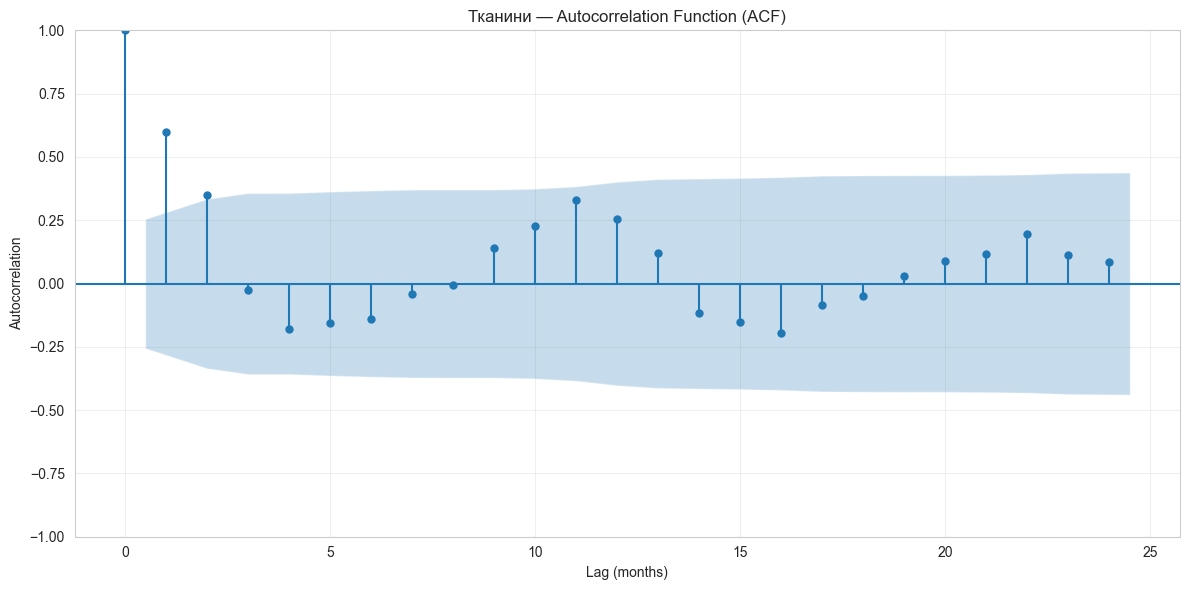


Тканини: Significant lags at: [1, 2, 11, 12]...
   → Lag 12 is significant — possible seasonality


In [695]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf

for store in ['Гудзики', 'Тканини']:

    monthly = sales[sales['store'] == store].groupby('date')['document number'].nunique()
    monthly = monthly.resample('M').sum()

    plt.figure(figsize=(12, 4))
    plot_acf(monthly, lags=24, alpha=0.05)
    plt.title(f'{store} — Autocorrelation Function (ACF)')
    plt.xlabel('Lag (months)')
    plt.ylabel('Autocorrelation')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    acf_values = acf(monthly, nlags=24)
    significant_lags = [i for i, val in enumerate(acf_values) if i > 0 and abs(val) > 1.96 / len(monthly)**0.5]
    print(f"\n{store}: Significant lags at: {significant_lags[:5]}...")
    if 12 in significant_lags:
        print(f"   → Lag 12 is significant — possible seasonality")
    else:
        print(f"   → Lag 12 is NOT significant — no strong seasonality")

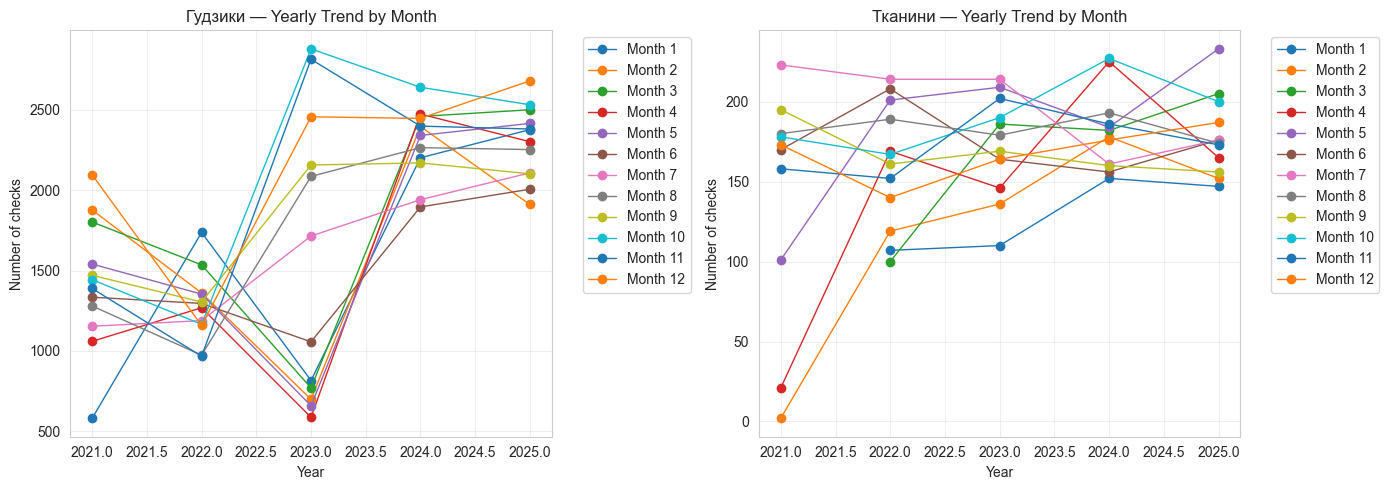

In [696]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, store in zip(axes, ['Гудзики', 'Тканини']):
    pivot = sales[sales['store'] == store].pivot_table(
        index='year', columns='month', values='document number', aggfunc='nunique'
    )

    for month in pivot.columns:
        ax.plot(pivot.index, pivot[month], marker='o', linewidth=1, label=f'Month {month}')
    
    ax.set_title(f'{store} — Yearly Trend by Month', fontsize=12)
    ax.set_xlabel('Year')
    ax.set_ylabel('Number of checks')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.2.5 Market Basket Analysis

In [698]:
gudzyky = sales[sales['store'] == 'Гудзики'].copy()

basket_sizes = gudzyky.groupby('document number')['item'].count()
multi_item = basket_sizes[basket_sizes >= 2].index
gudzyky_multi = gudzyky[gudzyky['document number'].isin(multi_item)]

print(f"Checks with 2+ items: {len(multi_item):,}")
print(f"{len(multi_item)/len(basket_sizes)*100:.1f}% of all checks")

pairs = Counter()
for receipt, group in gudzyky_multi.groupby('document number'):
    items = group['item'].unique().tolist()
    if len(items) >= 2:
        for pair in combinations(sorted(items), 2):
            pairs[pair] += 1

top_pairs = pd.DataFrame(
    [(a, b, count) for (a, b), count in pairs.most_common(20)],
    columns=['item_1', 'item_2', 'co_purchases']
)

total_receipts = len(multi_item)
top_pairs['support_%'] = (top_pairs['co_purchases'] / total_receipts * 100).round(2)

print("Top 20 pairs:")
print(top_pairs.to_string(index=False))

Checks with 2+ items: 47,907
45.1% of all checks
Top 20 pairs:
              item_1                        item_2  co_purchases  support_%
      40 біла 400ярд               40 чорна 400ярд          1261       2.63
     40 чорна 400ярд             мікс 40 полі естр           773       1.61
      40 біла 400ярд             мікс 40 полі естр           664       1.39
         бісер чехія                голкабісер с к           635       1.33
         бісер чехія          нитка бісер100м біла           370       0.77
         бісер чехія          нитка бісер200м біла           361       0.75
     40 чорна 400ярд           голка ручна pony 12           337       0.70
  п199 нитки 40 біла           п200 нитки 40 чорна           318       0.66
 голка ручна pony 12             мікс 40 полі естр           289       0.60
         бісер китай                   бісер чехія           257       0.54
      40 біла 400ярд           голка ручна pony 12           231       0.48
         бісер чехія     

In [699]:
gudzyky_all = sales[sales['store'] == 'Гудзики'].copy()

basket_sizes = gudzyky_all.groupby('document number')['item'].count()
multi_item = basket_sizes[basket_sizes >= 2].index
gudzyky_multi = gudzyky_all[gudzyky_all['document number'].isin(multi_item)]

pairs = Counter()
for receipt, group in gudzyky_multi.groupby('document number'):
    items = group['item'].unique().tolist()
    if len(items) >= 2:
        for pair in combinations(sorted(items), 2):
            pairs[pair] += 1

top_pairs_full = pd.DataFrame(
    [(a, b, count) for (a, b), count in pairs.most_common(200)],
    columns=['item_1', 'item_2', 'co_purchases']
)

all_items_in_pairs = set(top_pairs_full['item_1'].tolist() + 
                          top_pairs_full['item_2'].tolist())
print(f"Unique items in top-200 pairs: {len(all_items_in_pairs)}")
for item in sorted(all_items_in_pairs):
    print(f"  {item}")

Unique items in top-200 pairs: 155
  307 нитки дмс
  310 нитки дмс
  321 нитки дмс
  40 біла 400ярд
  40 мікс нпнк 10 шт
  40 поліестр катруся
  40 чорна 400ярд
  414 нитки дмс
  415 нитки дмс
  444 нитки дмс
  666 нитки дмс
  699 нитки дмс
  816 нитки дмс
  972 нитки дмс
  b5200 нитки дмс
  beissel stretch 75 6079
  beissel stretch 90 6080
  beissel universal 70 6068 stand
  beissel universal 80 6069 stand
  tytan 100м білі круг
  б008 35 50см н р пл
  б009 18см 4 кольор
  б011 35 100см пластм розємний
  б031 35 1м пл трактор
  б082 7 трак 60см 1м
  блиск спір рулонка т3 біла 501
  блістер galant 5763 для шиття3 9
  болти д ремня с к
  булав англ 2 8 с к sun
  булав англ 3 2 с к sun
  булав англ 3 8 с к sun
  булав англ 4 5 с к sun
  булав англ 5 6 с к sun
  булав англ 7 5 с к sun
  булав англ асорті с к sun
  булав маркер д вяз2 2 с к
  бігунок 5 трак
  бігунок 7 спіраль
  бігунок 8 трактор мо
  бігунок т3 пост біл
  бігунок т3 пост нікель
  бісер китай
  бісер чехія
  гач вяз алюмін

In [700]:
category_map = {
    # НИТКИ ДЛЯ ШИТТЯ
    'Thread & Sewing': [
        '40 біла 400ярд', '40 чорна 400ярд', '40 мікс нпнк 10 шт',
        '40 поліестр катруся', 'мікс 40 полі естр', 'мікс 20 джинс',
        'п199 нитки 40 біла', 'п200 нитки 40 чорна',
        'дп199 джинс 20 біла', 'дп200 джинс 20 чорна',
        'нитка ідеал біла с к', 'нитка ідеал чорна с к',
        'tytan 100м білі круг', 'дратва біла 375т', 'дратва чорна 375т',
        'моно нитка ск', 'нитки санкт петербург пнк 20м',
        'нитка ariadna польща 8м', 'нитка для вишивання с к',
        'нитка гумка біла', 'нитка гумка чорна',
    ],
    # НИТКИ ДМС (вишивка хрестиком)
    'Embroidery Thread (DMC)': [
        '307 нитки дмс', '310 нитки дмс', '321 нитки дмс',
        '414 нитки дмс', '415 нитки дмс', '444 нитки дмс',
        '666 нитки дмс', '699 нитки дмс', '816 нитки дмс',
        '972 нитки дмс', 'b5200 нитки дмс',
        'набір дит нитками олекс',
    ],
    # БІСЕР І БІЖУТЕРІЯ
    'Beading & Jewelry': [
        'бісер чехія', 'бісер китай',
        'голкабісер с к', 'голка crewei 7 0 7х38 5794',
        'голка бісер galant 10 13 5768',
        'нитка бісер100м біла', 'нитка бісер100м чорна',
        'нитка бісер200м біла', 'нитка бісер50м титан60',
        'застібка для біжутерії', 'застібка для біжутерії 3грн',
        'колечко на застібку', 'караб сумк 1 5см с ч з с к',
    ],
    # ГОЛКИ
    'Needles': [
        'голка ручна pony 12', 'голки ручні', 'голки рушничок',
        'голка гобилен0427 00 с к',
        'гол маш schmetz universal 100 6138',
        'гол маш schmetz universal 90',
        'гол маш standart 100 6071 чехія',
        'гол маш standart 90 6070',
        'beissel stretch 75 6079', 'beissel stretch 90 6080',
        'beissel universal 70 6068 stand',
        'beissel universal 80 6069 stand',
        'набір голк маяк с к',
        'нитквдягач пласт с к', 'нитковдягач пласт мо',
    ],
    # ЗАМКИ ТА БЛИСКАВКИ
    'Zippers & Fasteners': [
        'фм 159 с 2 15', 'фм 198 с 3 20',
        'фм 199 с 1 17', 'фм 199 с 2 23', 'фм 199 с 3 25',
        'блиск спір рулонка т3 біла 501',
        'бігунок т3 пост біл', 'бігунок т3 пост нікель',
        'бігунок 5 трак', 'бігунок 7 спіраль', 'бігунок 8 трактор мо',
        'б008 35 50см н р пл', 'б009 18см 4 кольор',
        'б011 35 100см пластм розємний', 'б031 35 1м пл трактор',
        'б082 7 трак 60см 1м',
        'фастекс 2 5см чор с к', 'болти д ремня с к',
    ],
    # ГУДЗИКИ
    'Buttons': [
        'гудз мікс 10', 'гудз мікс 8', 'гудз мікс 12', 'гудз мікс 15',
        'гудзикнабив d19 с к',
    ],
    # ГУМКА ТА РЕЗИНКА
    'Elastic & Rubber': [
        'гумка 2 5см б ч 10м', 'гумка 2см б ч 10м',
        'гумка 3см б ч 10м', 'гумка 3мм біла портной 180м',
        'гумка 3мм чорна портной 180м',
        'гумка подвій 6мм біла', 'гумка подвій 7мм біла',
        'гумкабілиз оzver 8мм біла с к',
        'гумкабілиз оzver 8мм чорн с к',
        'гум шляп 1мм чор біл с к', 'гум шляп 2 5мм кольор с к',
        'гум шляп боб 2 5 чорн портной 100м',
        'силіконова рез прозора 50м',
    ],
    # СТРІЧКИ ТА ТАСЬМА
    'Ribbons & Tape': [
        'стр атл 0 5см 8012 жовтий', 'стр атл 0 5см 8013 жовтий',
        'стр атл 0 5см 8055 червона', 'стр атл 0 5см 8107 електрик',
        'стр атл 12мм 8013 жовт', 'стр атл 12мм 8104 голуб',
        'стр атл 1см 8013 жовтий', 'стр атл 1см 8106 тем голб',
        'стр атл 2 5см 8012 жовт', 'стр атл 2 5см 8013 жовт',
        'стр атл 2 5см 8055 черв', 'стр атл 2 5см 8105 голуб',
        'стр атл 2 5см 8107 синій',
        'тасрепс жовт синя 1см 50м', 'тасрепс жовт синя 2 5см 45м',
        'тасрепс жовт синя 2см 50м',
        'тасьм ремін 2 5см чорн хакі46',
        'тасьма кіперна міх 1см 39м', 'тасьма кіперна міх 2см 39м',
        'крайки на метраж 5см', 'крайки на метраж 6 7см',
        'ліпучка 2 5см чорна', 'павутинка клей2смск',
        'павутинклей 3см с к 100м',
    ],
    # ШПИЛЬКИ ТА БУЛАВКИ
    'Pins & Clips': [
        'булав англ 2 8 с к sun', 'булав англ 3 2 с к sun',
        'булав англ 3 8 с к sun', 'булав англ 4 5 с к sun',
        'булав англ 5 6 с к sun', 'булав англ 7 5 с к sun',
        'булав англ асорті с к sun', 'булав маркер д вяз2 2 с к',
        'невидимка білі перли с к', 'гачки для карніза',
        'гач вяз алюмін руч 3мм с к',
    ],
    # АКСЕСУАРИ ТА ІНШЕ
    'Accessories & Other': [
        'блістер galant 5763 для шиття3 9',
        'ножиці stafil манікюрні',
        'сантим стрічка в кор', 'сантиметрова стр',
        'плечики ч б 5 6',
        'заст д бюст 2 гачка с к',
        'подовжувач до бюст 2 гачка ч б беж с к',
        'подовжувач до бюст 3 гачка ч б беж',
        'жилка моно 12мм біла', 'жилка моно біла 150м',
        'шнур вощений декор 1 5мм 70м', 'шнур вощений декор 1мм 70м',
        'шнурівки фабрик плюс', 'фетр 2мм25х25',
        'термо аплікації fashion stile', 'термоаплікац с о',
        'нашивки партріотичні', 'нашивки шкіряні с о',
        'патріотичні нашивки', 'прапори великі',
        'стр атл 0 5см 8107 електрик',
        'тканини луцьк білі мікс', 'тканини луцьк льон мікс',
        'панама', 'гачки для карніза',
    ],
}

item_to_category = {}
for cat, items in category_map.items():
    for item in items:
        item_to_category[item] = cat

covered = set(item_to_category.keys())
all_items = set(all_items_in_pairs)
uncovered = all_items - covered

top_pairs_full['category_1'] = top_pairs_full['item_1'].map(item_to_category).fillna('Other')
top_pairs_full['category_2'] = top_pairs_full['item_2'].map(item_to_category).fillna('Other')

print("\n--- Pairs within one category ---")
same_cat = top_pairs_full[top_pairs_full['category_1'] == top_pairs_full['category_2']]
print(same_cat.groupby('category_1')['co_purchases'].agg(['count','sum','mean']).round(1).sort_values('sum', ascending=False))

print("\n--- Pairs within different categories ---")
cross_cat = top_pairs_full[top_pairs_full['category_1'] != top_pairs_full['category_2']]
print(cross_cat.head(10)[['item_1', 'category_1', 'item_2', 'category_2', 'co_purchases']])


--- Pairs within one category ---
                         count   sum   mean
category_1                                 
Thread & Sewing             26  4176  160.6
Beading & Jewelry           22  2815  128.0
Embroidery Thread (DMC)     14   890   63.6
Ribbons & Tape              10   497   49.7
Pins & Clips                 7   478   68.3
Zippers & Fasteners          8   476   59.5
Elastic & Rubber             5   285   57.0
Needles                      6   240   40.0
Accessories & Other          5   220   44.0
Buttons                      3   183   61.0

--- Pairs within different categories ---
                  item_1         category_1                         item_2  \
6        40 чорна 400ярд    Thread & Sewing            голка ручна pony 12   
8    голка ручна pony 12            Needles              мікс 40 полі естр   
10        40 біла 400ярд    Thread & Sewing            голка ручна pony 12   
11           бісер чехія  Beading & Jewelry           жилка моно біла 150м   
14  

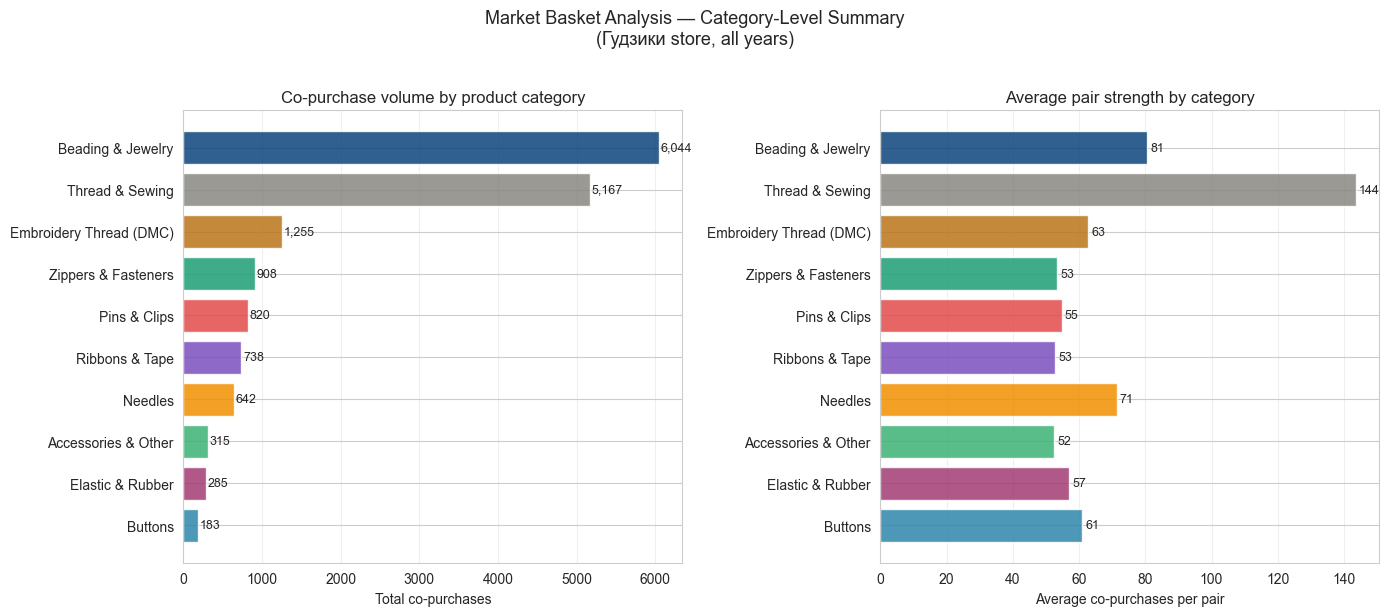

Category                        Pairs    Total    Avg
-------------------------------------------------------
Beading & Jewelry                  75     6044   80.6
Thread & Sewing                    36     5167  143.5
Embroidery Thread (DMC)            20     1255   62.8
Zippers & Fasteners                17      908   53.4
Pins & Clips                       15      820   54.7
Ribbons & Tape                     14      738   52.7
Needles                             9      642   71.3
Accessories & Other                 6      315   52.5
Elastic & Rubber                    5      285   57.0
Buttons                             3      183   61.0
pair_cats
Accessories & Other ↔ Beading & Jewelry      1266
Needles ↔ Thread & Sewing                     892
Beading & Jewelry ↔ Elastic & Rubber          795
Beading & Jewelry ↔ Ribbons & Tape            604
Beading & Jewelry ↔ Needles                   512
Embroidery Thread (DMC) ↔ Thread & Sewing     417
Beading & Jewelry ↔ Pins & Clips        

In [535]:
cat_summary = top_pairs_full.groupby('category_1')['co_purchases'].agg(['count','sum','mean']).round(1)
cat_summary.columns = ['pairs_count', 'total_copurchases', 'avg_copurchases']
cat_summary = cat_summary.sort_values('total_copurchases', ascending=True)

colors = ['#2E86AB', '#A23B72', '#3BB273', '#F18F01', '#7B4FBF',
          '#E24B4A', '#1D9E75', '#BA7517', '#888780', '#0C447C']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bars = axes[0].barh(cat_summary.index, cat_summary['total_copurchases'],
                    color=colors[:len(cat_summary)], alpha=0.85)
axes[0].set_xlabel('Total co-purchases')
axes[0].set_title('Co-purchase volume by product category')
axes[0].grid(True, axis='x', alpha=0.3)
for bar, val in zip(bars, cat_summary['total_copurchases']):
    axes[0].text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
                f'{int(val):,}', va='center', fontsize=9)

bars2 = axes[1].barh(cat_summary.index, cat_summary['avg_copurchases'],
                     color=colors[:len(cat_summary)], alpha=0.85)
axes[1].set_xlabel('Average co-purchases per pair')
axes[1].set_title('Average pair strength by category')
axes[1].grid(True, axis='x', alpha=0.3)
for bar, val in zip(bars2, cat_summary['avg_copurchases']):
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f'{val:.0f}', va='center', fontsize=9)

plt.suptitle('Market Basket Analysis — Category-Level Summary\n(Гудзики store, all years)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_2_7_category_basket.png', dpi=150)
plt.show()

print(f"{'Category':<30} {'Pairs':>6} {'Total':>8} {'Avg':>6}")
print("-" * 55)
for cat, row in cat_summary.sort_values('total_copurchases', ascending=False).iterrows():
    print(f"{cat:<30} {int(row['pairs_count']):>6} {int(row['total_copurchases']):>8} {row['avg_copurchases']:>6.1f}")

cross = top_pairs_full[top_pairs_full['category_1'] != top_pairs_full['category_2']].copy()
cross['pair_cats'] = cross.apply(
    lambda r: ' ↔ '.join(sorted([r['category_1'], r['category_2']])), axis=1)
cross_agg = cross.groupby('pair_cats')['co_purchases'].sum().sort_values(ascending=False).head(10)
print(cross_agg.to_string())

### 5.1 ABC-XYZ Classification

##### 5.1.1 Pareto Analysis (ABC Classification)

In [536]:
product_stats = sales.groupby(['store', 'item'])['revenue'].sum().reset_index()
product_stats.columns = ['store', 'item', 'revenue']

In [537]:
product_stats['rank'] = product_stats.groupby('store')['revenue'].rank(method='first', ascending=False)
product_stats = product_stats.sort_values(['store', 'revenue'], ascending=[True, False])
product_stats['cum_revenue'] = product_stats.groupby('store')['revenue'].cumsum()
total_rev = product_stats.groupby('store')['revenue'].transform('sum')
product_stats['cum_share'] = product_stats['cum_revenue'] / total_rev

In [702]:
for store in ['Гудзики', 'Тканини']:
    subset = product_stats[product_stats['store'] == store]
    n_products = len(subset)
    n_80 = subset[subset['cum_share'] <= 0.8]['item'].nunique()
    pct = n_80 / n_products * 100
    
    print(f"\n{store}:")
    print(f"  All Items: {n_products}")
    print(f"  Items that generate 80% of revenue: {n_80} ({pct:.1f}%)")
    print(f"  Other {n_products - n_80} item ({100-pct:.1f}%) generate 20% revenue")


Гудзики:
  Items: 11073
  Items that generate 80% of revenue: 2035 (18.4%)
  Other 9038 item (81.6%) generate 20% revenue

Тканини:
  Items: 141
  Items that generate 80% of revenue: 30 (21.3%)
  Other 111 item (78.7%) generate 20% revenue


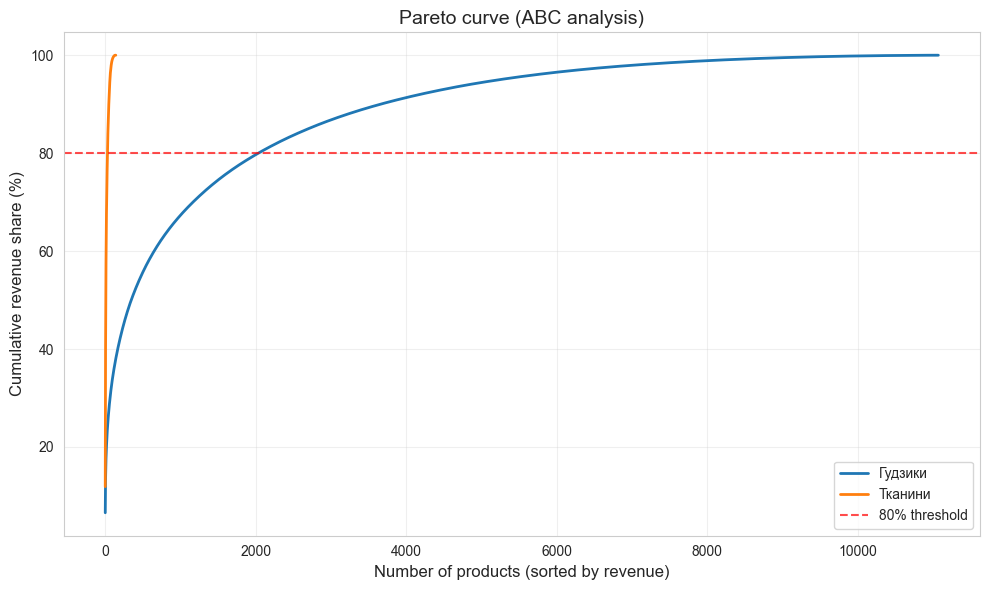

In [703]:
plt.figure(figsize=(10, 6))
for store in ['Гудзики', 'Тканини']:
    subset = product_stats[product_stats['store'] == store]
    plt.plot(range(1, len(subset) + 1), subset['cum_share'] * 100, 
             label=f'{store}', linewidth=2)

plt.axhline(80, color='red', linestyle='--', alpha=0.7, label='80% threshold')
plt.xlabel('Number of products (sorted by revenue)', fontsize=12)
plt.ylabel('Cumulative revenue share (%)', fontsize=12)
plt.title('Pareto curve (ABC analysis)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### 5.1.2 XYZ Analysis

In [704]:
sales_2024_2025 = sales[sales['date'] >= '2024-01-01'].copy()
weekly_data = sales_2024_2025.groupby(['store', 'item', pd.Grouper(key='date', freq='W')])['quantity'].sum().reset_index()

xyz_calc = weekly_data.groupby(['store', 'item'])['quantity'].agg(
    lambda x: x.std() / x.mean() if x.mean() > 0 else np.nan
).reset_index()
xyz_calc.columns = ['store', 'item', 'cv']

xyz_calc = xyz_calc.dropna()

final_results = []

for store in xyz_calc['store'].unique():
    store_data = xyz_calc[xyz_calc['store'] == store].copy()

    q33 = store_data['cv'].quantile(0.33)
    q66 = store_data['cv'].quantile(0.66)
    
    print(f"\n--- Store: {store} ---")
    print(f"X threshold (33rd percentile): {q33:.2f}")
    print(f"Y threshold (66th percentile): {q66:.2f}")

    def assign_xyz(cv, q33, q66):
        if cv <= q33: return 'X'
        if cv <= q66: return 'Y'
        return 'Z'
    
    store_data['XYZ'] = store_data['cv'].apply(lambda x: assign_xyz(x, q33, q66))
    final_results.append(store_data)

xyz_final = pd.concat(final_results)

print("\nCategory distribution after quantization:")
print(xyz_final.groupby(['store', 'XYZ']).size().unstack(fill_value=0))


--- Store: Гудзики ---
X threshold (33rd percentile): 0.43
Y threshold (66th percentile): 0.78

--- Store: Тканини ---
X threshold (33rd percentile): 0.73
Y threshold (66th percentile): 0.97

Category distribution after quantization:
XYZ         X     Y     Z
store                    
Гудзики  1477  1475  1521
Тканини    34    33    35


##### 5.1.3 ABC-XYZ Matrix

In [705]:
sales_2024_2025 = sales[sales['date'] >= '2024-01-01'].copy()

abc_raw = sales_2024_2025.groupby(['store', 'item'])['revenue'].sum().reset_index()

weekly_sales = sales_2024_2025.groupby(['store', 'item', pd.Grouper(key='date', freq='W')])['quantity'].sum().reset_index()
xyz_raw = weekly_sales.groupby(['store', 'item'])['quantity'].agg(
    lambda x: x.std() / x.mean() if x.mean() > 0 else np.nan
).reset_index()
xyz_raw.columns = ['store', 'item', 'cv']

abc_xyz_2025 = abc_raw.merge(xyz_raw, on=['store', 'item']).dropna()

final_list = []

for store in abc_xyz_2025['store'].unique():
    df_s = abc_xyz_2025[abc_xyz_2025['store'] == store].copy()

    df_s = df_s.sort_values('revenue', ascending=False)
    df_s['cum_rev_share'] = df_s['revenue'].cumsum() / df_s['revenue'].sum()
    
    def get_abc(share):
        if share <= 0.80: return 'A'
        if share <= 0.95: return 'B'
        return 'C'
    
    df_s['ABC'] = df_s['cum_rev_share'].apply(get_abc)

    q33 = df_s['cv'].quantile(0.33)
    q66 = df_s['cv'].quantile(0.66)
    
    def get_xyz(cv, q1, q2):
        if cv <= q1: return 'X'
        if cv <= q2: return 'Y'
        return 'Z'
    
    df_s['XYZ'] = df_s['cv'].apply(lambda x: get_xyz(x, q33, q66))
    df_s['ABC_XYZ'] = df_s['ABC'] + df_s['XYZ']
    
    final_list.append(df_s)

    print(f"Store: {store} | ABC (A/B/C items): {list(df_s['ABC'].value_counts().sort_index().values)}")
    print(f"Store: {store} | XYZ Thresholds: X <= {q33:.2f}, Y <= {q66:.2f}\n")

abc_xyz_final = pd.concat(final_list)

for store in abc_xyz_final['store'].unique():
    print(f"\n{store.upper()}:")
    subset = abc_xyz_final[abc_xyz_final['store'] == store]
    matrix = subset.pivot_table(index='ABC', columns='XYZ', values='item', aggfunc='count', fill_value=0)
    print(matrix)

    counts = subset['ABC_XYZ'].value_counts().sort_index()
    total = len(subset)
    print(f"\nTotal items: {total}")
    for group, count in counts.items():
        print(f"  {group}: {count} items ({count/total*100:.1f}%)")

Store: Гудзики | ABC (A/B/C items): [1007, 1495, 1971]
Store: Гудзики | XYZ Thresholds: X <= 0.43, Y <= 0.78

Store: Тканини | ABC (A/B/C items): [28, 28, 46]
Store: Тканини | XYZ Thresholds: X <= 0.73, Y <= 0.97


ГУДЗИКИ:
XYZ    X    Y    Z
ABC               
A    130  345  532
B    483  480  532
C    864  650  457

Total items: 4473
  AX: 130 items (2.9%)
  AY: 345 items (7.7%)
  AZ: 532 items (11.9%)
  BX: 483 items (10.8%)
  BY: 480 items (10.7%)
  BZ: 532 items (11.9%)
  CX: 864 items (19.3%)
  CY: 650 items (14.5%)
  CZ: 457 items (10.2%)

ТКАНИНИ:
XYZ   X   Y   Z
ABC            
A     3   6  19
B     9  10   9
C    22  17   7

Total items: 102
  AX: 3 items (2.9%)
  AY: 6 items (5.9%)
  AZ: 19 items (18.6%)
  BX: 9 items (8.8%)
  BY: 10 items (9.8%)
  BZ: 9 items (8.8%)
  CX: 22 items (21.6%)
  CY: 17 items (16.7%)
  CZ: 7 items (6.9%)


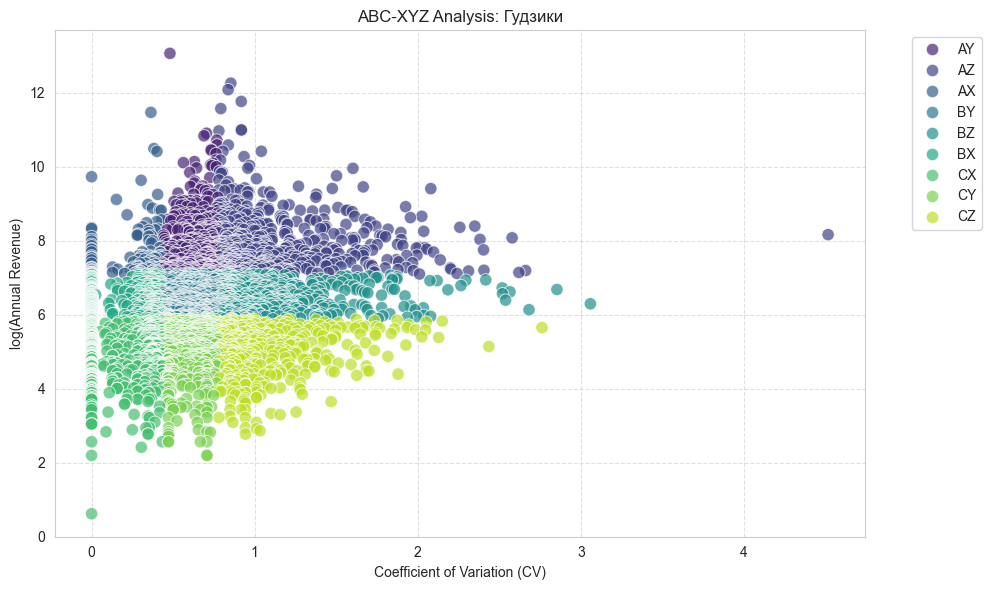

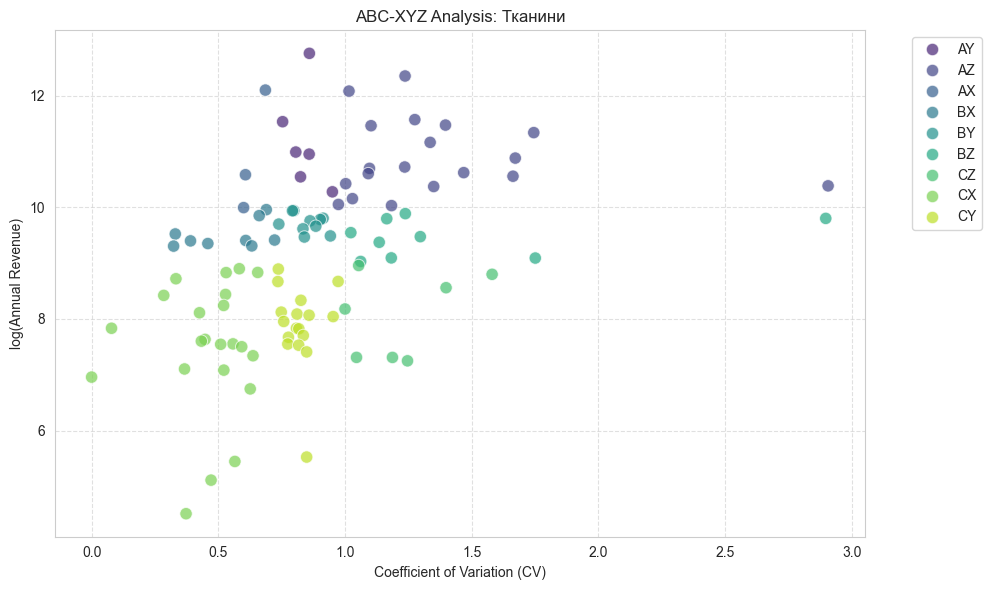

In [706]:
for store in abc_xyz_final['store'].unique():
    subset = abc_xyz_final[abc_xyz_final['store'] == store].copy()

    subset['log_revenue'] = np.log1p(subset['revenue'])
    
    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=subset, 
        x='cv', 
        y='log_revenue', 
        hue='ABC_XYZ', 
        palette='viridis', 
        alpha=0.7, 
        s=80
    )
    
    plt.title(f'ABC-XYZ Analysis: {store}')
    plt.xlabel('Coefficient of Variation (CV)')
    plt.ylabel('log(Annual Revenue)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

##### 5.1.4 Classification Stability Analysis

In [707]:
def get_refined_abc_xyz(df_input):
    """
    Takes sales dataframe, returns segmentation based on weekly CV and quantiles.
    """
    results = []
    
    for store in df_input['store'].unique():
        store_data = df_input[df_input['store'] == store].copy()

        weekly = store_data.groupby(['item', pd.Grouper(key='date', freq='W')])['quantity'].sum().reset_index()
        
        cv_data = weekly.groupby('item')['quantity'].agg(
            lambda x: x.std() / x.mean() if x.mean() > 0 else np.nan
        ).reset_index()
        cv_data.columns = ['item', 'cv']
        cv_data = cv_data.dropna()

        q33 = cv_data['cv'].quantile(0.33)
        q66 = cv_data['cv'].quantile(0.66)
        
        def assign_xyz(cv):
            if cv <= q33: return 'X'
            if cv <= q66: return 'Y'
            return 'Z'
        
        cv_data['XYZ'] = cv_data['cv'].apply(assign_xyz)

        rev_data = store_data.groupby('item')['revenue'].sum().reset_index()
        rev_data = rev_data.sort_values('revenue', ascending=False)
        rev_data['cum_share'] = rev_data['revenue'].cumsum() / rev_data['revenue'].sum()
        
        def assign_abc(share):
            if share <= 0.80: return 'A'
            if share <= 0.95: return 'B'
            return 'C'
        
        rev_data['ABC'] = rev_data['cum_share'].apply(assign_abc)

        store_res = rev_data.merge(cv_data, on='item')
        store_res['ABC_XYZ'] = store_res['ABC'] + store_res['XYZ']
        store_res['store'] = store
        results.append(store_res[['store', 'item', 'ABC_XYZ']])
        
    return pd.concat(results)

years_count = sales.groupby(['store', 'item'])['year'].nunique().reset_index()
long_lived_items = years_count[years_count['year'] == 5][['store', 'item']]

print(f"Long-lived products found: {len(long_lived_items)}")

long_lived_sales = sales.merge(long_lived_items, on=['store', 'item'])

sales_2025 = long_lived_sales[long_lived_sales['year'] == 2025]
abc_xyz_2025 = get_refined_abc_xyz(sales_2025)

abc_xyz_all = get_refined_abc_xyz(long_lived_sales)

comparison = abc_xyz_2025.merge(
    abc_xyz_all, on=['store', 'item'], suffixes=('_2025', '_FullHistory')
)

for store in comparison['store'].unique():
    store_comp = comparison[comparison['store'] == store]
    changed = store_comp[store_comp['ABC_XYZ_2025'] != store_comp['ABC_XYZ_FullHistory']]
    
    print(f"\nStore: {store}")
    print(f" Total long-lived products: {len(store_comp)}")
    print(f"  Unchanged category: {len(store_comp) - len(changed)} products")
    print(f"  Changed category: {len(changed)} products ({len(changed)/len(store_comp)*100:.1f}%)")
    
    print("\n   Distribution of groups in 2025 (for long-lived products):")
    print(store_comp['ABC_XYZ_2025'].value_counts().sort_index())

Long-lived products found: 1723

Store: Гудзики
 Total long-lived products: 1385
  Unchanged category: 600 products
  Changed category: 785 products (56.7%)

   Distribution of groups in 2025 (for long-lived products):
ABC_XYZ_2025
AX     32
AY    130
AZ    165
BX    135
BY    177
BZ    180
CX    290
CY    150
CZ    126
Name: count, dtype: int64

Store: Тканини
 Total long-lived products: 56
  Unchanged category: 19 products
  Changed category: 37 products (66.1%)

   Distribution of groups in 2025 (for long-lived products):
ABC_XYZ_2025
AX     5
AY     4
AZ    11
BX     4
BY     8
BZ     4
CX    10
CY     6
CZ     4
Name: count, dtype: int64


In [708]:
for store in comparison['store'].unique():
    store_comp = comparison[comparison['store'] == store]

    dist_2025 = store_comp['ABC_XYZ_2025'].value_counts().sort_index()

    dist_all = store_comp['ABC_XYZ_FullHistory'].value_counts().sort_index()

    all_groups = sorted(set(dist_2025.index) | set(dist_all.index))
    

    print(f"Store: {store}")
    print(f"{'Category':<8} {'2025 year':<12} {'All years':<12} {'Change':<10}")
    print(f"{'-'*45}")
    
    for group in all_groups:
        c2025 = dist_2025.get(group, 0)
        call = dist_all.get(group, 0)
        change = c2025 - call
        change_str = f"+{change}" if change > 0 else str(change)
        print(f"{group:<8} {c2025:<12} {call:<12} {change_str:<10}")

    total_2025 = len(store_comp)
    changed = store_comp[store_comp['ABC_XYZ_2025'] != store_comp['ABC_XYZ_FullHistory']]
    stable = total_2025 - len(changed)
    
    print(f"\n{'─'*45}")
    print(f"Total long-lived products:    {total_2025}")
    print(f"Unchanged category:   {stable} ({stable/total_2025*100:.1f}%)")
    print(f"Changed category:         {len(changed)} ({len(changed)/total_2025*100:.1f}%)")

Store: Гудзики
Category 2025 year    All years    Change    
---------------------------------------------
AX       32           89           -57       
AY       130          162          -32       
AZ       165          168          -3        
BX       135          128          +7        
BY       177          185          -8        
BZ       180          184          -4        
CX       290          207          +83       
CY       150          116          +34       
CZ       126          146          -20       

─────────────────────────────────────────────
Total long-lived products:    1385
Unchanged category:   600 (43.3%)
Changed category:         785 (56.7%)
Store: Тканини
Category 2025 year    All years    Change    
---------------------------------------------
AX       5            2            +3        
AY       4            10           -6        
AZ       11           10           +1        
BX       4            6            -2        
BY       8            5           

### 5.2 Demand Forecasting

##### 5.2.1 Aggregated Benchmark at Store Level

              MAPE (%)
Naive            82.92
SMA (7 днів)     36.84
ARIMA(1,1,1)     33.86


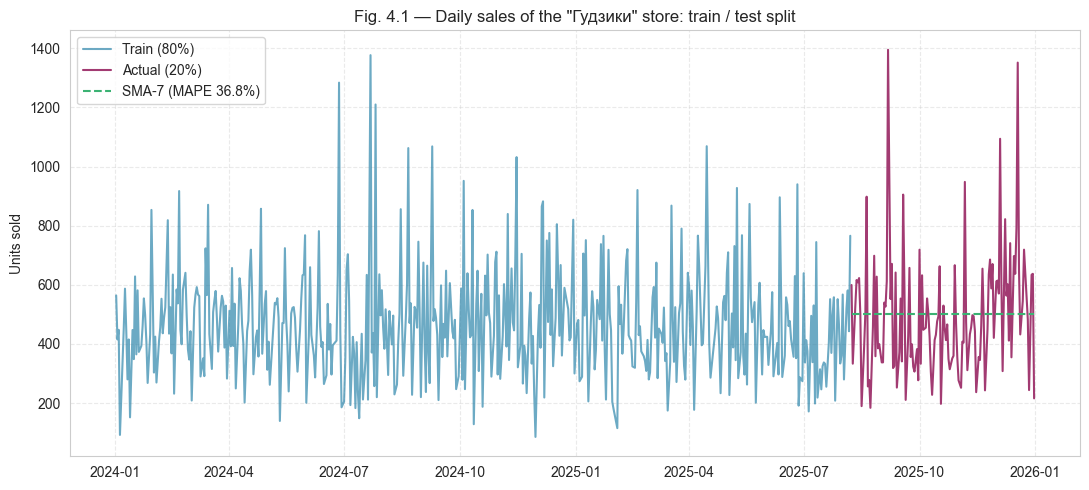

In [709]:
STORE       = 'Гудзики'
TARGET_GROUP = 'AX'
FIGSIZE     = (11, 5)
COLORS      = {'train': '#2E86AB', 'actual': '#A23B72', 'forecast': '#F18F01',
               'sma': '#3BB273', 'prophet': '#7B4FBF'}


store_daily = (
    sales_2024_2025[sales_2024_2025['store'] == STORE]
    .groupby('date')['quantity'].sum()
    .sort_index()
)

split = int(len(store_daily) * 0.8)
train_d, test_d = store_daily.iloc[:split], store_daily.iloc[split:]


def _mape(true, pred):
    return mean_absolute_percentage_error(true, pred) * 100


bench = {}
bench['Naive']        = _mape(test_d, np.full(len(test_d), train_d.iloc[-1]))
bench['SMA (7 днів)'] = _mape(test_d, np.full(len(test_d), train_d.iloc[-7:].mean()))
try:
    m_arima = ARIMA(train_d, order=(1, 1, 1)).fit()
    bench['ARIMA(1,1,1)'] = _mape(test_d, m_arima.forecast(steps=len(test_d)))
except Exception as e:
    bench['ARIMA(1,1,1)'] = np.nan
    print(f"  ARIMA не збіглась: {e}")

bench_df = (
    pd.DataFrame.from_dict(bench, orient='index', columns=['MAPE (%)'])
    .round(2)
)
print(bench_df.to_string())

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(train_d.index, train_d.values, color=COLORS['train'],
        lw=1.5, label='Train (80%)', alpha=0.7)
ax.plot(test_d.index, test_d.values, color=COLORS['actual'],
        lw=1.5, label='Actual (20%)')
ax.plot(test_d.index,
        np.full(len(test_d), train_d.iloc[-7:].mean()),
        color=COLORS['sma'], lw=1.5, ls='--',
        label=f"SMA-7 (MAPE {bench['SMA (7 днів)']:.1f}%)")
ax.set_title('Fig. 4.1 — Daily sales of the "Гудзики" store: train / test split', fontsize=12)
ax.set_ylabel('Units sold')
ax.legend(fontsize=10)
ax.grid(True, ls='--', alpha=0.4)
plt.tight_layout()
plt.show()

##### 5.2.2 Comparative Model Analysis on AX Group

In [547]:
def _mape(true, pred):
    return mean_absolute_percentage_error(true, pred) * 100

STORE = 'Гудзики'
TARGET_GROUP = 'AX'

ax_items = abc_xyz_final[abc_xyz_final['ABC_XYZ'] == TARGET_GROUP]['item'].unique()

ax_monthly = (
    sales_2024_2025[
        (sales_2024_2025['store'] == STORE) &
        (sales_2024_2025['item'].isin(ax_items))
    ]
    .groupby(pd.Grouper(key='date', freq='M'))['quantity']
    .sum()
    .sort_index()
)

print(f"Period: {ax_monthly.index[0].strftime('%b %Y')} - {ax_monthly.index[-1].strftime('%b %Y')}")
print(f"Total months: {len(ax_monthly)}")
print()

Period: Jan 2024 - Dec 2025
Total months: 24



In [548]:
def tune_parameters(train, val):
    """Підбір параметрів"""
 
    windows = [2, 3, 4, 6, 8, 10, 12]
    best_window = None
    best_sma_mape = float('inf')
    
    for w in windows:
        if len(train) >= w:
            pred_val = np.full(len(val), train.iloc[-w:].mean())
            mape = _mape(val, pred_val)
            if mape < best_sma_mape:
                best_sma_mape = mape
                best_window = w

    alphas = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    best_alpha = None
    best_ses_mape = float('inf')
    
    for alpha in alphas:
        try:
            ses_model = ExponentialSmoothing(train, trend=None, seasonal=None).fit(smoothing_level=alpha)
            pred_val = ses_model.forecast(len(val))
            mape = _mape(val, pred_val)
            if mape < best_ses_mape:
                best_ses_mape = mape
                best_alpha = alpha
        except:
            continue
    
    return {
        'sma_window': best_window,
        'ses_alpha': best_alpha,
        'arima_order': (1, 1, 1)
    }

In [549]:
def evaluate_on_test(train, test, params):
    results = {}

    sma_pred = np.full(len(test), train.iloc[-params['sma_window']:].mean())
    results['SMA'] = _mape(test, sma_pred)

    ses_model = ExponentialSmoothing(train, trend=None, seasonal=None).fit(smoothing_level=params['ses_alpha'])
    ses_pred = ses_model.forecast(len(test))
    results['SES'] = _mape(test, ses_pred)

    arima_model = ARIMA(train, order=params['arima_order']).fit()
    arima_pred = arima_model.forecast(steps=len(test))
    results['ARIMA(1,1,1)'] = _mape(test, arima_pred)

    df_train = train.reset_index()
    df_train.columns = ['ds', 'y']
    mp = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
    mp.fit(df_train)
    future = mp.make_future_dataframe(periods=len(test), freq='M')
    fc = mp.predict(future)
    prophet_pred = fc['yhat'].iloc[-len(test):].values
    results['Prophet'] = _mape(test, prophet_pred)
    
    return results

In [713]:
train1 = ax_monthly[:'2025-04-30']
val1 = ax_monthly['2025-05-01':'2025-07-31']
test1 = ax_monthly['2025-08-01':]

print(f"Train: {train1.index[0].strftime('%b %Y')} – {train1.index[-1].strftime('%b %Y')} ({len(train1)} міс.)")
print(f"Validation: {val1.index[0].strftime('%b %Y')} – {val1.index[-1].strftime('%b %Y')} ({len(val1)} міс.)")
print(f"Test:  {test1.index[0].strftime('%b %Y')} – {test1.index[-1].strftime('%b %Y')} ({len(test1)} міс.)")
print(f"Test values: {test1.values.round(2)}")

params1 = tune_parameters(train1, val1)
print(f"\nParameters:")
print(f"  SMA window: {params1['sma_window']}")
print(f"  SES alpha: {params1['ses_alpha']}")
print(f"  ARIMA order: {params1['arima_order']}")

results1 = evaluate_on_test(train1, test1, params1)

print("\nResults on test:")
for model, mape in sorted(results1.items(), key=lambda x: x[1]):
    print(f"  {model}: MAPE = {mape:.2f}%")

best1 = min(results1, key=lambda x: results1[x])
print(f"\nBest: {best1} ({results1[best1]:.2f}%)")

13:38:03 - cmdstanpy - INFO - Chain [1] start processing
13:38:03 - cmdstanpy - INFO - Chain [1] done processing


Train: Jan 2024 – Apr 2025 (16 міс.)
Validation: May 2025 – Jul 2025 (3 міс.)
Test:  Aug 2025 – Dec 2025 (5 міс.)
Test values: [397.87 369.75 384.19 417.1  379.67]

Parameters:
  SMA window: 6
  SES alpha: 0.9
  ARIMA order: (1, 1, 1)

Results on test:
  SES: MAPE = 3.87%
  SMA: MAPE = 4.06%
  Prophet: MAPE = 4.20%
  ARIMA(1,1,1): MAPE = 6.26%

Best: SES (3.87%)


In [714]:
train2 = ax_monthly[:'2025-09-30']
val2 = ax_monthly['2025-07-01':'2025-09-30']
test2 = ax_monthly['2025-10-01':]

print(f"Train: {train2.index[0].strftime('%b %Y')} – {train2.index[-1].strftime('%b %Y')} ({len(train2)} міс.)")
print(f"Validation: {val2.index[0].strftime('%b %Y')} – {val2.index[-1].strftime('%b %Y')} ({len(val2)} міс.)")
print(f"Test:  {test2.index[0].strftime('%b %Y')} – {test2.index[-1].strftime('%b %Y')} ({len(test2)} міс.)")
print(f"Test values: {test2.values.round(2)}")

params2 = tune_parameters(train2, val2)
print(f"\nParameters:")
print(f"  SMA window: {params2['sma_window']}")
print(f"  SES alpha: {params2['ses_alpha']}")
print(f"  ARIMA order: {params2['arima_order']}")

results2 = evaluate_on_test(train2, test2, params2)

print("\nResults on test:")
for model, mape in sorted(results2.items(), key=lambda x: x[1]):
    print(f"  {model}: MAPE = {mape:.2f}%")

best2 = min(results2, key=lambda x: results2[x])
print(f"\nBest: {best2} ({results2[best2]:.2f}%)")

13:38:06 - cmdstanpy - INFO - Chain [1] start processing
13:38:06 - cmdstanpy - INFO - Chain [1] done processing


Train: Jan 2024 – Sep 2025 (21 міс.)
Validation: Jul 2025 – Sep 2025 (3 міс.)
Test:  Oct 2025 – Dec 2025 (3 міс.)
Test values: [384.19 417.1  379.67]

Parameters:
  SMA window: 4
  SES alpha: 0.9
  ARIMA order: (1, 1, 1)

Results on test:
  ARIMA(1,1,1): MAPE = 3.75%
  Prophet: MAPE = 5.13%
  SES: MAPE = 5.30%
  SMA: MAPE = 6.74%

Best: ARIMA(1,1,1) (3.75%)


In [715]:
train3 = ax_monthly[:'2025-06-30']
val3 = ax_monthly['2025-04-01':'2025-06-30']
test3 = ax_monthly['2025-07-01':]

print(f"Train: {train3.index[0].strftime('%b %Y')} – {train3.index[-1].strftime('%b %Y')} ({len(train3)} міс.)")
print(f"Validation: {val3.index[0].strftime('%b %Y')} – {val3.index[-1].strftime('%b %Y')} ({len(val3)} міс.)")
print(f"Test:  {test3.index[0].strftime('%b %Y')} – {test3.index[-1].strftime('%b %Y')} ({len(test3)} міс.)")
print(f"Test values: {test3.values.round(2)}")

params3 = tune_parameters(train3, val3)
print(f"\nParameters:")
print(f"  SMA window: {params3['sma_window']}")
print(f"  SES alpha: {params3['ses_alpha']}")
print(f"  ARIMA order: {params3['arima_order']}")

results3 = evaluate_on_test(train3, test3, params3)

print("\nResults on test:")
for model, mape in sorted(results3.items(), key=lambda x: x[1]):
    print(f"  {model}: MAPE = {mape:.2f}%")

best3 = min(results3, key=lambda x: results3[x])
print(f"\nBest: {best3} ({results3[best3]:.2f}%)")

13:38:44 - cmdstanpy - INFO - Chain [1] start processing
13:38:44 - cmdstanpy - INFO - Chain [1] done processing


Train: Jan 2024 – Jun 2025 (18 міс.)
Validation: Apr 2025 – Jun 2025 (3 міс.)
Test:  Jul 2025 – Dec 2025 (6 міс.)
Test values: [355.47 397.87 369.75 384.19 417.1  379.67]

Parameters:
  SMA window: 3
  SES alpha: 0.6
  ARIMA order: (1, 1, 1)

Results on test:
  SMA: MAPE = 4.31%
  Prophet: MAPE = 4.44%
  SES: MAPE = 5.08%
  ARIMA(1,1,1): MAPE = 7.11%

Best: SMA (4.31%)


In [717]:
summary = pd.DataFrame({
    'Test 1 (Aug–Dec)': results1,
    'Test 2 (Oct–Dec)': results2,
    'Test 3 (Jul–Dec)': results3
}).round(2)

print(summary.to_string())

print('\n')

print(f"  Test 1 (Aug–Dec 2025): {best1} ({results1[best1]:.2f}%)")
print(f"  Test 2 (Oct–Dec 2025): {best2} ({results2[best2]:.2f}%)")
print(f"  Test 3 (Jul–Dec 2025): {best3} ({results3[best3]:.2f}%)")

              Test 1 (Aug–Dec)  Test 2 (Oct–Dec)  Test 3 (Jul–Dec)
SMA                       4.06              6.74              4.31
SES                       3.87              5.30              5.08
ARIMA(1,1,1)              6.26              3.75              7.11
Prophet                   4.20              5.13              4.44


  Test 1 (Aug–Dec 2025): SES (3.87%)
  Test 2 (Oct–Dec 2025): ARIMA(1,1,1) (3.75%)
  Test 3 (Jul–Dec 2025): SMA (4.31%)


##### 5.2.3 Model Stability Assessment: Rolling Cross-Validation

In [718]:
def _mape(true, pred):
    return mean_absolute_percentage_error(true, pred) * 100

STORE = 'Гудзики'
TARGET_GROUP = 'AX'

ax_items = abc_xyz_final[abc_xyz_final['ABC_XYZ'] == TARGET_GROUP]['item'].unique()

ax_monthly = (
    sales_2024_2025[
        (sales_2024_2025['store'] == STORE) &
        (sales_2024_2025['item'].isin(ax_items))
    ]
    .groupby(pd.Grouper(key='date', freq='M'))['quantity']
    .sum()
    .sort_index()
)

def sma_forecast(train, window=3):
    """SMA з фіксованим вікном"""
    if len(train) >= window:
        return train.iloc[-window:].mean()
    return train.mean()

def ses_forecast(train):
    """SES з alpha=0.5 (за замовчуванням)"""
    try:
        model = ExponentialSmoothing(train, trend=None, seasonal=None).fit()
        return model.forecast(1).iloc[0]
    except:
        return train.mean()

def arima_forecast(train, order=(1, 1, 1)):
    """ARIMA(1,1,1)"""
    try:
        model = ARIMA(train, order=order).fit()
        return model.forecast(steps=1).iloc[0]
    except:
        return train.iloc[-1]

def prophet_forecast(train):
    """Prophet"""
    try:
        df_train = train.reset_index()
        df_train.columns = ['ds', 'y']
        mp = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
        mp.fit(df_train)
        future = mp.make_future_dataframe(periods=1, freq='M')
        fc = mp.predict(future)
        return fc['yhat'].iloc[-1]
    except:
        return train.iloc[-1]


In [719]:
sma_window = 3
cv_results = {
    'SMA': [],
    'SES': [],
    'ARIMA(1,1,1)': [],
    'Prophet': []
}

for i in range(6, len(ax_monthly) - 1):
    train = ax_monthly.iloc[:i]
    actual = ax_monthly.iloc[i]
    
    # SMA
    pred_sma = sma_forecast(train, window=sma_window)
    cv_results['SMA'].append(_mape([actual], [pred_sma]))
    
    # SES
    pred_ses = ses_forecast(train)
    cv_results['SES'].append(_mape([actual], [pred_ses]))
    
    # ARIMA(1,1,1)
    pred_arima = arima_forecast(train)
    cv_results['ARIMA(1,1,1)'].append(_mape([actual], [pred_arima]))
    
    # Prophet
    pred_prophet = prophet_forecast(train)
    cv_results['Prophet'].append(_mape([actual], [pred_prophet]))

13:39:45 - cmdstanpy - INFO - Chain [1] start processing
13:39:45 - cmdstanpy - INFO - Chain [1] done processing
13:39:45 - cmdstanpy - INFO - Chain [1] start processing
13:39:45 - cmdstanpy - INFO - Chain [1] done processing
13:39:46 - cmdstanpy - INFO - Chain [1] start processing
13:39:46 - cmdstanpy - INFO - Chain [1] done processing
13:39:46 - cmdstanpy - INFO - Chain [1] start processing
13:39:46 - cmdstanpy - INFO - Chain [1] done processing
13:39:46 - cmdstanpy - INFO - Chain [1] start processing
13:39:46 - cmdstanpy - INFO - Chain [1] done processing
13:39:46 - cmdstanpy - INFO - Chain [1] start processing
13:39:46 - cmdstanpy - INFO - Chain [1] done processing
13:39:46 - cmdstanpy - INFO - Chain [1] start processing
13:39:46 - cmdstanpy - INFO - Chain [1] done processing
13:39:46 - cmdstanpy - INFO - Chain [1] start processing
13:39:46 - cmdstanpy - INFO - Chain [1] done processing
13:39:46 - cmdstanpy - INFO - Chain [1] start processing
13:39:46 - cmdstanpy - INFO - Chain [1]

In [720]:
for model in cv_results:
    scores = [x for x in cv_results[model] if not np.isnan(x)]
    if scores:
        avg = np.mean(scores)
        std = np.std(scores)
        min_val = np.min(scores)
        max_val = np.max(scores)
        print(f"{model}:")
        print(f"  Average MAPE: {avg:.1f}%")
        print(f"  Standard deviation: {std:.1f}%")
        print(f"  Min/Max: {min_val:.1f}% / {max_val:.1f}%")
        print()

SMA:
  Average MAPE: 9.4%
  Standard deviation: 6.0%
  Min/Max: 0.4% / 20.0%

SES:
  Average MAPE: 8.5%
  Standard deviation: 5.7%
  Min/Max: 0.6% / 20.6%

ARIMA(1,1,1):
  Average MAPE: 8.6%
  Standard deviation: 5.7%
  Min/Max: 0.8% / 20.7%

Prophet:
  Average MAPE: 9.5%
  Standard deviation: 5.4%
  Min/Max: 2.3% / 21.5%



In [721]:
summary = []
for model in cv_results:
    scores = [x for x in cv_results[model] if not np.isnan(x)]
    if scores:
        summary.append({
            'Model': model,
            'CV MAPE (%)': round(np.mean(scores), 1),
            'Std (%)': round(np.std(scores), 1),
            'Min (%)': round(np.min(scores), 1),
            'Max (%)': round(np.max(scores), 1)
        })

summary_df = pd.DataFrame(summary)
summary_df = summary_df.sort_values('CV MAPE (%)')
print(summary_df.to_string(index=False))

       Model  CV MAPE (%)  Std (%)  Min (%)  Max (%)
         SES          8.5      5.7      0.6     20.6
ARIMA(1,1,1)          8.6      5.7      0.8     20.7
         SMA          9.4      6.0      0.4     20.0
     Prophet          9.5      5.4      2.3     21.5


##### 5.2.4 Forecastability of Different Product Groups

In [722]:
STORE = 'Гудзики'
GROUPS_TO_TEST = ['AY', 'AZ', 'BZ','BX','BY']

def evaluate_group(group_name):
    """Оцінка прогнозування для заданої групи"""
    items = abc_xyz_final[
        (abc_xyz_final['store'] == STORE) & 
        (abc_xyz_final['ABC_XYZ'] == group_name)
    ]['item'].unique()
    
    if len(items) == 0:
        print(f"Група {group_name}: немає товарів")
        return None
    
    monthly = (
        sales_2024_2025[
            (sales_2024_2025['store'] == STORE) &
            (sales_2024_2025['item'].isin(items))
        ]
        .groupby(pd.Grouper(key='date', freq='M'))['quantity']
        .sum()
        .sort_index()
    )
    
    train = monthly[:'2025-09-30']
    test = monthly['2025-10-01':]
    
    if len(train) < 6 or len(test) == 0:
        print(f"Група {group_name}: недостатньо даних")
        return None

    sma_pred = np.full(len(test), train.mean())
    sma_mape = _mape(test, sma_pred)

    try:
        ses_model = ExponentialSmoothing(train, trend=None, seasonal=None).fit()
        ses_pred = ses_model.forecast(len(test))
        ses_mape = _mape(test, ses_pred)
    except:
        ses_mape = np.nan

    try:
        arima_model = ARIMA(train, order=(1, 1, 1)).fit()
        arima_pred = arima_model.forecast(steps=len(test))
        arima_mape = _mape(test, arima_pred)
    except:
        arima_mape = np.nan

    try:
        df_train = train.reset_index()
        df_train.columns = ['ds', 'y']
        mp = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
        mp.fit(df_train)
        future = mp.make_future_dataframe(periods=len(test), freq='M')
        fc = mp.predict(future)
        prophet_pred = fc['yhat'].iloc[-len(test):].values
        prophet_mape = _mape(test, prophet_pred)
    except:
        prophet_mape = np.nan
    
    return {
        'group': group_name,
        'n_items': len(items),
        'train_months': len(train),
        'SMA': sma_mape,
        'SES': ses_mape,
        'ARIMA': arima_mape,
        'Prophet': prophet_mape
    }

group_results = []
for group in GROUPS_TO_TEST:
    res = evaluate_group(group)
    if res:
        group_results.append(res)

print("-" * 60)
df_groups = pd.DataFrame(group_results)
print(df_groups.round(2).to_string(index=False))

13:40:52 - cmdstanpy - INFO - Chain [1] start processing
13:40:52 - cmdstanpy - INFO - Chain [1] done processing
13:40:52 - cmdstanpy - INFO - Chain [1] start processing
13:40:52 - cmdstanpy - INFO - Chain [1] done processing
13:40:53 - cmdstanpy - INFO - Chain [1] start processing
13:40:53 - cmdstanpy - INFO - Chain [1] done processing
13:40:53 - cmdstanpy - INFO - Chain [1] start processing
13:40:53 - cmdstanpy - INFO - Chain [1] done processing
13:40:53 - cmdstanpy - INFO - Chain [1] start processing
13:40:53 - cmdstanpy - INFO - Chain [1] done processing


------------------------------------------------------------
group  n_items  train_months   SMA   SES  ARIMA  Prophet
   AY      345            21  7.10  8.49   8.45    12.20
   AZ      532            21 14.80 18.12  21.70    20.88
   BZ      532            21 29.39 25.23  25.41    20.35
   BX      483            21 23.79 31.57  28.05    33.88
   BY      480            21  8.70 23.83  19.82    38.01


In [724]:
STORE = 'Гудзики'
GROUPS_TO_TEST = ['AY', 'AZ', 'BZ','BY','BX']
sma_window = 3

def rolling_cv_for_group(group_name):
    """Rolling CV"""
    items = abc_xyz_final[
        (abc_xyz_final['store'] == STORE) & 
        (abc_xyz_final['ABC_XYZ'] == group_name)
    ]['item'].unique()
    
    if len(items) == 0:
        return None

    monthly = (
        sales_2024_2025[
            (sales_2024_2025['store'] == STORE) &
            (sales_2024_2025['item'].isin(items))
        ]
        .groupby(pd.Grouper(key='date', freq='M'))['quantity']
        .sum()
        .sort_index()
    )
    
    if len(monthly) < 12:
        return None

    cv_results = {'SMA': [], 'SES': [], 'ARIMA(1,1,1)': [], 'Prophet': []}
    
    for i in range(6, len(monthly) - 1):
        train = monthly.iloc[:i]
        actual = monthly.iloc[i]

        sma_pred = train.iloc[-sma_window:].mean()
        cv_results['SMA'].append(_mape([actual], [sma_pred]))

        try:
            ses_model = ExponentialSmoothing(train, trend=None, seasonal=None).fit()
            ses_pred = ses_model.forecast(1).iloc[0]
            cv_results['SES'].append(_mape([actual], [ses_pred]))
        except:
            cv_results['SES'].append(np.nan)

        try:
            arima_model = ARIMA(train, order=(1, 1, 1)).fit()
            arima_pred = arima_model.forecast(steps=1).iloc[0]
            cv_results['ARIMA(1,1,1)'].append(_mape([actual], [arima_pred]))
        except:
            cv_results['ARIMA(1,1,1)'].append(np.nan)

        try:
            df_train = train.reset_index()
            df_train.columns = ['ds', 'y']
            mp = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
            mp.fit(df_train)
            future = mp.make_future_dataframe(periods=1, freq='M')
            fc = mp.predict(future)
            prophet_pred = fc['yhat'].iloc[-1]
            cv_results['Prophet'].append(_mape([actual], [prophet_pred]))
        except:
            cv_results['Prophet'].append(np.nan)

    summary = {}
    for model, scores in cv_results.items():
        valid = [x for x in scores if not np.isnan(x)]
        if valid:
            summary[model] = {
                'cv_mape': np.mean(valid),
                'cv_std': np.std(valid)
            }
    
    return {
        'group': group_name,
        'n_items': len(items),
        'cv': summary
    }

cv_group_results = []
for group in GROUPS_TO_TEST:
    res = rolling_cv_for_group(group)
    if res:
        cv_group_results.append(res)

print("ROLLING CV RESULTS (1-month-ahead, MAPE %):")
print("-" * 70)

for res in cv_group_results:
    print(f"\nCategory {res['group']} (items: {res['n_items']}):")
    for model, metrics in res['cv'].items():
        print(f"  {model}: avarage MAPE = {metrics['cv_mape']:.1f}%, std = {metrics['cv_std']:.1f}%")

13:42:12 - cmdstanpy - INFO - Chain [1] start processing
13:42:12 - cmdstanpy - INFO - Chain [1] done processing
13:42:12 - cmdstanpy - INFO - Chain [1] start processing
13:42:12 - cmdstanpy - INFO - Chain [1] done processing
13:42:12 - cmdstanpy - INFO - Chain [1] start processing
13:42:12 - cmdstanpy - INFO - Chain [1] done processing
13:42:13 - cmdstanpy - INFO - Chain [1] start processing
13:42:13 - cmdstanpy - INFO - Chain [1] done processing
13:42:13 - cmdstanpy - INFO - Chain [1] start processing
13:42:13 - cmdstanpy - INFO - Chain [1] done processing
13:42:13 - cmdstanpy - INFO - Chain [1] start processing
13:42:13 - cmdstanpy - INFO - Chain [1] done processing
13:42:13 - cmdstanpy - INFO - Chain [1] start processing
13:42:13 - cmdstanpy - INFO - Chain [1] done processing
13:42:13 - cmdstanpy - INFO - Chain [1] start processing
13:42:13 - cmdstanpy - INFO - Chain [1] done processing
13:42:13 - cmdstanpy - INFO - Chain [1] start processing
13:42:13 - cmdstanpy - INFO - Chain [1]

ROLLING CV RESULTS (1-month-ahead, MAPE %):
----------------------------------------------------------------------

Category AY (items: 345):
  SMA: avarage MAPE = 12.5%, std = 9.7%
  SES: avarage MAPE = 13.6%, std = 6.4%
  ARIMA(1,1,1): avarage MAPE = 16.1%, std = 5.7%
  Prophet: avarage MAPE = 15.2%, std = 10.9%

Category AZ (items: 532):
  SMA: avarage MAPE = 13.7%, std = 6.8%
  SES: avarage MAPE = 12.8%, std = 6.7%
  ARIMA(1,1,1): avarage MAPE = 15.2%, std = 8.5%
  Prophet: avarage MAPE = 13.5%, std = 9.6%

Category BZ (items: 532):
  SMA: avarage MAPE = 16.0%, std = 13.7%
  SES: avarage MAPE = 16.5%, std = 12.7%
  ARIMA(1,1,1): avarage MAPE = 18.8%, std = 16.7%
  Prophet: avarage MAPE = 14.1%, std = 11.7%

Category BY (items: 480):
  SMA: avarage MAPE = 17.5%, std = 10.4%
  SES: avarage MAPE = 19.5%, std = 10.5%
  ARIMA(1,1,1): avarage MAPE = 18.6%, std = 9.4%
  Prophet: avarage MAPE = 17.9%, std = 10.8%

Category BX (items: 483):
  SMA: avarage MAPE = 20.6%, std = 17.1%
  SES: av

##### 5.2.5 Impact of Aggregation Level on Forecast Accuracy

sku level

In [725]:
top_sku = (
    sales_2024_2025[
        (sales_2024_2025['store'] == STORE) &
        (sales_2024_2025['item'].isin(ax_items))
    ]
    .groupby('item')['quantity'].sum()
    .idxmax()
)

print(f"Selected SKU: {top_sku}")

sku_daily = (
    sales_2024_2025[sales_2024_2025['item'] == top_sku]
    .groupby('date')['quantity'].sum()
    .reindex(pd.date_range('2024-01-01', '2025-12-31'), fill_value=0)
)

sku_monthly = sku_daily.resample('M').sum()

train_sku = sku_monthly[:'2025-09-30']
test_sku = sku_monthly['2025-10-01':]

print(f"SKU train: {len(train_sku)} months, SKU test: {len(test_sku)} months\n")

sku_results = {}

sma_pred = np.full(len(test_sku), train_sku.mean())
sku_results['SMA — SKU'] = _mape(test_sku, sma_pred)

# --- SES ---
try:
    ses_model = ExponentialSmoothing(train_sku, trend=None, seasonal=None).fit()
    ses_pred = ses_model.forecast(len(test_sku))
    sku_results['SES — SKU'] = _mape(test_sku, ses_pred)
except:
    sku_results['SES — SKU'] = np.nan

# --- ARIMA(1,1,1) ---
try:
    arima_model = ARIMA(train_sku, order=(1, 1, 1)).fit()
    arima_pred = arima_model.forecast(steps=len(test_sku))
    sku_results['ARIMA(1,1,1) — SKU'] = _mape(test_sku, arima_pred)
except:
    sku_results['ARIMA(1,1,1) — SKU'] = np.nan

# --- Prophet ---
try:
    df_train = train_sku.reset_index()
    df_train.columns = ['ds', 'y']
    mp = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
    mp.fit(df_train)
    future = mp.make_future_dataframe(periods=len(test_sku), freq='M')
    fc = mp.predict(future)
    prophet_pred = fc['yhat'].iloc[-len(test_sku):].values
    sku_results['Prophet — SKU'] = _mape(test_sku, prophet_pred)
except:
    sku_results['Prophet — SKU'] = np.nan

group_results = {
    'SMA — Group': 9.4,
    'SES — Group': 8.5,
    'ARIMA(1,1,1) — Group': 8.6,
    'Prophet — Group': 9.5
}

all_comparison = {}

for model_sku, mape_sku in sku_results.items():
    if not np.isnan(mape_sku):
        if 'SMA' in model_sku:
            model_group = 'SMA — Group'
        elif 'SES' in model_sku:
            model_group = 'SES — Group'
        elif 'ARIMA' in model_sku:
            model_group = 'ARIMA(1,1,1) — Group'
        elif 'Prophet' in model_sku:
            model_group = 'Prophet — Group'
        else:
            continue
        
        mape_group = group_results.get(model_group, np.nan)
        
        print(f"\n{model_sku.replace(' — SKU', '')}:")
        print(f"  SKU level:   {mape_sku:.1f}%")
        print(f"  Group level: {mape_group:.1f}%")
        print(f"  Improvement:   {mape_sku - mape_group:.1f} p.p.")

13:43:50 - cmdstanpy - INFO - Chain [1] start processing


Selected SKU: мікс 40 полі естр
SKU train: 21 months, SKU test: 3 months



13:43:50 - cmdstanpy - INFO - Chain [1] done processing



SMA:
  SKU level:   17.9%
  Group level: 9.4%
  Improvement:   8.5 p.p.

SES:
  SKU level:   18.3%
  Group level: 8.5%
  Improvement:   9.8 p.p.

ARIMA(1,1,1):
  SKU level:   18.6%
  Group level: 8.6%
  Improvement:   10.0 p.p.

Prophet:
  SKU level:   10.6%
  Group level: 9.5%
  Improvement:   1.1 p.p.


##### 5.2.6 Forecasting for the “Тканини” Store

In [727]:
STORE_F = 'Тканини'
COLORS  = {'train': '#2E86AB', 'actual': '#A23B72',
           'sma': '#3BB273', 'arima': '#F18F01', 'prophet': '#7B4FBF'}

def _mape(true, pred):
    return mean_absolute_percentage_error(true, pred) * 100

def _wape(true, pred):
    return np.sum(np.abs(np.array(true) - np.array(pred))) / np.sum(np.abs(np.array(true))) * 100

fabric_in_matrix = sales_2024_2025[sales_2024_2025['store'] == STORE_F]['item'].unique()
fabric_abc = abc_xyz_final[abc_xyz_final['item'].isin(fabric_in_matrix)]

ax_fabric_items = fabric_abc[fabric_abc['ABC_XYZ'] == 'AX']['item'].unique()
print(f"AX products in Тканини: {len(ax_fabric_items)}")

fabric_monthly = (
    sales_2024_2025[
        (sales_2024_2025['store'] == STORE_F) &
        (sales_2024_2025['item'].isin(ax_fabric_items))
    ]
    .groupby(pd.Grouper(key='date', freq='M'))['quantity']
    .sum()
    .sort_index()
)

train_f = fabric_monthly.iloc[:-3]
test_f  = fabric_monthly.iloc[-3:]

print(f"\nTrain: {train_f.index[0].strftime('%b %Y')} – {train_f.index[-1].strftime('%b %Y')}")
print(f"Test:  {test_f.index[0].strftime('%b %Y')} – {test_f.index[-1].strftime('%b %Y')}")
print(f"\nMonthly volume (units):")
print(f"  Train — min: {train_f.min():.1f}, max: {train_f.max():.1f}, mean: {train_f.mean():.1f}")
print(f"  Test  — {list(test_f.round(2).values)}")

results = {}

# 1. SMA
sma_pred = np.full(len(test_f), train_f.mean())
results['Simple Moving Average'] = {
    'pred': sma_pred,
    'MAE':   mean_absolute_error(test_f, sma_pred),
    'RMSE':  np.sqrt(mean_squared_error(test_f, sma_pred)),
    'MAPE':  _mape(test_f, sma_pred),
    'WAPE':  _wape(test_f.values, sma_pred),
}

# 2. ARIMA(1,1,1)
try:
    m_ar = ARIMA(train_f, order=(1, 1, 1)).fit()
    arima_pred = m_ar.forecast(steps=3).values
    results['ARIMA(1,1,1)'] = {
        'pred': arima_pred,
        'MAE':   mean_absolute_error(test_f, arima_pred),
        'RMSE':  np.sqrt(mean_squared_error(test_f, arima_pred)),
        'MAPE':  _mape(test_f, arima_pred),
        'WAPE':  _wape(test_f.values, arima_pred),
    }
except Exception as e:
    print(f"ARIMA failed: {e}")
    results['ARIMA(1,1,1)'] = {'pred': np.full(3, np.nan),
                                'MAE': np.nan, 'RMSE': np.nan,
                                'MAPE': np.nan, 'WAPE': np.nan}

# 3. Prophet
try:
    df_p = train_f.reset_index()
    df_p.columns = ['ds', 'y']
    mp = Prophet(yearly_seasonality=False, weekly_seasonality=False,
                 daily_seasonality=False)
    mp.fit(df_p)
    future = mp.make_future_dataframe(periods=3, freq='ME')
    fc = mp.predict(future)
    prophet_pred = fc['yhat'].iloc[-3:].values
    results['Prophet'] = {
        'pred': prophet_pred,
        'MAE':   mean_absolute_error(test_f, prophet_pred),
        'RMSE':  np.sqrt(mean_squared_error(test_f, prophet_pred)),
        'MAPE':  _mape(test_f, prophet_pred),
        'WAPE':  _wape(test_f.values, prophet_pred),
    }
except Exception as e:
    print(f"Prophet failed: {e}")
    results['Prophet'] = {'pred': np.full(3, np.nan),
                          'MAE': np.nan, 'RMSE': np.nan,
                          'MAPE': np.nan, 'WAPE': np.nan}


print("Table 4.5 — Model accuracy for Тканини (AX group, Q4 2025)")

metrics_f = pd.DataFrame({
    k: {'MAE': v['MAE'], 'RMSE': v['RMSE'],
        'MAPE (%)': v['MAPE'], 'WAPE (%)': v['WAPE']}
    for k, v in results.items()
}).T.round(2)

print(metrics_f.to_string())

winner = metrics_f['WAPE (%)'].idxmin()
print(f"\nBest model by WAPE: {winner} ({metrics_f.loc[winner,'WAPE (%)']:.1f}%)")


print("Table 4.6 — Cross-store comparison (SMA, AX group)")

comparison = pd.DataFrame({
    'Гудзики': {
        'AX products count': 119,
        'Revenue share of AX (%)': 27.3,
        'Average monthly volume': 376.8,
        'SMA MAPE (%)': 5.37,
        'SMA WAPE (%)': 5.21,
    },
    'Тканини': {
        'AX products count': 8,
        'Revenue share of AX (%)': None, 
        'Average monthly volume': round(train_f.mean(), 1),
        'SMA MAPE (%)': round(results['Simple Moving Average']['MAPE'], 2),
        'SMA WAPE (%)': round(results['Simple Moving Average']['WAPE'], 2),
    }
}).T

print(comparison.to_string())

13:44:55 - cmdstanpy - INFO - Chain [1] start processing
13:44:55 - cmdstanpy - INFO - Chain [1] done processing


AX products in Тканини: 6

Train: Jan 2024 – Sep 2025
Test:  Oct 2025 – Dec 2025

Monthly volume (units):
  Train — min: 0.0, max: 36.5, mean: 11.9
  Test  — [21.15, 12.1, 24.5]
Table 4.5 — Model accuracy for Тканини (AX group, Q4 2025)
                        MAE   RMSE  MAPE (%)  WAPE (%)
Simple Moving Average  7.35   9.03     32.28     38.19
ARIMA(1,1,1)           8.46   9.89     38.82     43.94
Prophet                9.95  11.27     47.02     51.69

Best model by WAPE: Simple Moving Average (38.2%)
Table 4.6 — Cross-store comparison (SMA, AX group)
         AX products count  Revenue share of AX (%)  Average monthly volume  SMA MAPE (%)  SMA WAPE (%)
Гудзики              119.0                     27.3                   376.8          5.37          5.21
Тканини                8.0                      NaN                    11.9         32.28         38.19


Inventory Health

In [728]:
sales_2025 = sales[sales['year'] == 2025]

sales_frequency = sales_2025[sales_2025['store'] == 'Тканини'].groupby('item')['date'].nunique()
total_quantity = sales_2025[sales_2025['store'] == 'Тканини'].groupby('item')['quantity'].sum()

def classify_3_categories(days):
    if days <= 5:
        return 'Dead Stock'
    elif days <= 30:
        return 'Slow Moving'
    else:
        return 'Fast Moving'

inventory_health = pd.DataFrame({
    'days_with_sales': sales_frequency,
    'total_quantity': total_quantity
})
inventory_health['category'] = inventory_health['days_with_sales'].apply(classify_3_categories)

category_counts = inventory_health['category'].value_counts()
total_products = len(inventory_health)

dead_items = inventory_health[inventory_health['category'] == 'Dead Stock'].index
dead_revenue = sales_2025[
    (sales_2025['store'] == 'Тканини') & 
    (sales_2025['item'].isin(dead_items))
]['revenue'].sum()
total_revenue = sales_2025[sales_2025['store'] == 'Тканини']['revenue'].sum()

print(f"\nTotal products: {total_products}")
print(f"Dead Stock (≤5 days): {category_counts.get('Dead Stock', 0)} products ({category_counts.get('Dead Stock', 0)/total_products*100:.1f}%) — revenue {dead_revenue/total_revenue*100:.1f}%")
print(f"Slow Moving (6-30 days): {category_counts.get('Slow Moving', 0)} products ({category_counts.get('Slow Moving', 0)/total_products*100:.1f}%)")
print(f"Fast Moving (>30 days): {category_counts.get('Fast Moving', 0)} products ({category_counts.get('Fast Moving', 0)/total_products*100:.1f}%)")

print(f"\nCandidates for delisting (Dead + Slow): {category_counts.get('Dead Stock', 0) + category_counts.get('Slow Moving', 0)} products")


Total products: 103
Dead Stock (≤5 days): 42 products (40.8%) — revenue 5.6%
Slow Moving (6-30 days): 37 products (35.9%)
Fast Moving (>30 days): 24 products (23.3%)

Candidates for delisting (Dead + Slow): 79 products
